# Trends

## Preparation

In [ ]:
import xarray as xr
import numpy as np
import matplotlib as mpl
import matplotlib.pyplot as plt
from scipy import odr

from lcc_trend_analysis.paths import get_data_paths
from lcc_trend_analysis.observations.utils import (
    get_ground_sites_gdf,
)

In [ ]:
sites = get_ground_sites_gdf()
analysis_sites = [
    "cabauw",
    "chilbolton",
    "flesland",
    "graciosa",
    "granada",
    "kenttarova",
    "juelich",
    "kumpula",
    "lauder",
    "lindenberg",
    "nsa",
    "oslo",
    "palaiseau",
    "payerne",
    "sgp",
    "vehmasmaki",
]
analysis_sites = sorted(
    analysis_sites, key=lambda site: sites.loc[site, "humanReadableName"]
)

In [ ]:
results_path = get_data_paths().results / "trends_and_responses"

In [ ]:
ds_trends = xr.open_dataset(
    get_data_paths().level4_trends / "cloud_cover_trends.nc"
)
ds_trends_daytime = xr.open_dataset(
    get_data_paths().level4_trends / "cloud_cover_trends_daytime.nc"
)
ds_trends_nighttime = xr.open_dataset(
    get_data_paths().level4_trends / "cloud_cover_trends_nighttime.nc"
)

In [ ]:
figwidth = 20 / 2.56

font = {"size": 7}

mpl.rc("font", **font)

In [ ]:
analysis_sites = [
    "cabauw",
    "chilbolton",
    "flesland",
    "graciosa",
    "granada",
    "kenttarova",
    "juelich",
    "kumpula",
    "lauder",
    "lindenberg",
    "nsa",
    "oslo",
    "palaiseau",
    "payerne",
    "sgp",
    "vehmasmaki",
]

In [ ]:
# Source: Beck, H.E., N.E. Zimmermann, T.R. McVicar, N. Vergopolan, A. Berg, E.F. Wood: Present and future Köppen-Geiger climate classification maps at 1-km resolution, Nature Scientific Data, 2018.
climate_classification = {
    "cabauw": "Cfb",
    "chilbolton": "Cfb",
    "flesland": "Cfb",
    "graciosa": "Csa",
    "granada": "Csa",
    "kenttarova": "Dfc",
    "juelich": "Cfb",
    "kumpula": "Dfb",
    "lauder": "BSk",
    "lindenberg": "Dfb",
    "nsa": "ET",
    "oslo": "Dfb",
    "palaiseau": "Cfb",
    "payerne": "Dfb",
    "sgp": "Cfa",
    "vehmasmaki": "Dfc",
}

climate_classification_descriptions = {
    "BSk": "Cold semi-arid (BSk)",
    "Cfa": "Humid subtropical (Cfa)",
    "Cfb": "Marine mild winter (Cfb)",
    "Csa": "Hot-summer Mediterranean (Csa)",
    "Dfb": "Warm-summer humid continental (Dfb)",
    "Dfc": "Subarctic (Dfc)",
    "ET": "Tundra (ET)",
}

# Build a Köppen-aware palette: same first letter -> same hue family
present_classes = sorted(set(climate_classification.values()))
classes_by_main = {}
for cls in present_classes:
    classes_by_main.setdefault(cls[0], []).append(cls)

# Fixed base hues per Köppen main group (A, B, C, D, E)
base_hue = {
    "A": 0.10,  # warm
    "B": 0.08,  # arid orange
    "C": 0.33,  # temperate green
    "D": 0.58,  # continental blue
    "E": 0.75,  # polar violet
}

climate_color_map = {}
for main, cls_list in classes_by_main.items():
    cls_list = sorted(cls_list)
    n = len(cls_list)
    # Keep hue almost fixed within group; vary saturation/value for subclasses
    sats = np.linspace(0.55, 0.85, n) if n > 1 else np.array([0.70])
    vals = np.linspace(0.90, 0.65, n) if n > 1 else np.array([0.80])

    for i, cls in enumerate(cls_list):
        h = base_hue.get(main, 0.0)
        rgb = mpl.colors.hsv_to_rgb([h, sats[i], vals[i]])
        climate_color_map[cls] = (*rgb, 1.0)

climate_descriptions = {
    cls: climate_classification_descriptions[cls] for cls in present_classes
}

# Convenience arrays in site order
climate_labels = [climate_classification[s] for s in analysis_sites]
climate_colors = np.array([climate_color_map[c] for c in climate_labels])

In [ ]:
np.unique(climate_labels, return_counts=True)

(array(['BSk', 'Cfa', 'Cfb', 'Csa', 'Dfb', 'Dfc', 'ET'], dtype='<U3'),
 array([1, 1, 5, 2, 4, 2, 1]))

In [ ]:
ds_trends = ds_trends.sel(site=analysis_sites)
# ds_trends_daytime = ds_trends_daytime.sel(site=analysis_sites)
# ds_trends_nighttime = ds_trends_nighttime.sel(site=analysis_sites)

In [ ]:
import pandas as pd
from scipy.special import logsumexp
from scipy.optimize import minimize

trend_slope_distributions_path = (
    get_data_paths().level4_trends_slope_distributions
)


def load_trend_slope_quantile_function(dataset_name, site, suffix=""):
    """Load a full-year trend-slope quantile function parquet file.

    Returns the dataframe with `probability_level` and
    `quantile_value_per_year` columns (plus metadata), or None if the file
    does not exist for this dataset/site/suffix combination.
    """
    path = (
        trend_slope_distributions_path
        / f"{dataset_name}_{site}_trend_slope_distribution{suffix}.parquet"
    )
    if not path.exists():
        return None
    return pd.read_parquet(path)


def load_seasonal_trend_slope_quantile_function(
    dataset_name, site, season, suffix=""
):
    """Load a per-season trend-slope quantile function parquet file.

    Returns the dataframe with `probability_level` and
    `quantile_value_per_year` columns (plus metadata), or None if the file
    does not exist for this dataset/site/season/suffix combination.
    """
    path = (
        trend_slope_distributions_path
        / f"{dataset_name}_{site}_{season}_trend_slope_distribution{suffix}.parquet"
    )
    if not path.exists():
        return None
    return pd.read_parquet(path)


def resample_quantile_function(probability_levels, quantile_values, n_points):
    """Resample a quantile function at `n_points` evenly spaced probabilities.

    This yields a deterministic, low-variance ("stratified") representative
    ensemble of the underlying distribution -- the same idea as
    inverse-transform sampling, but without random draws, so that functions
    of these ensembles (e.g. the regression log-likelihood below) are
    deterministic in the fit parameters.
    """
    probe_levels = np.linspace(0.0, 1.0, n_points)
    return np.interp(probe_levels, probability_levels, quantile_values)


def _grid_log_mean_gaussian_density(
    x_ensemble, y_ensemble, beta0, beta1, sigma_int
):
    """Log of the ensemble-grid-averaged Gaussian density for one observation.

    Computes
        log( (1 / (n_x * n_y)) * sum_kl N(y_ensemble[l]; beta0 + beta1 * x_ensemble[k], sigma_int^2) )
    using the log-sum-exp trick for numerical stability.
    """
    mu = beta0 + beta1 * x_ensemble  # (n_x,)
    residual = y_ensemble[None, :] - mu[:, None]  # (n_x, n_y)
    log_density = -0.5 * np.log(2.0 * np.pi * sigma_int**2) - 0.5 * (
        residual**2
    ) / (sigma_int**2)
    return logsumexp(log_density) - np.log(log_density.size)


def _unpack_ml_regression_params(
    theta, fit_intrinsic_scatter, sigma_int_floor
):
    beta0, beta1 = float(theta[0]), float(theta[1])
    if fit_intrinsic_scatter:
        sigma_int = max(float(np.exp(theta[2])), sigma_int_floor)
    else:
        sigma_int = sigma_int_floor
    return beta0, beta1, sigma_int


def _ml_regression_neg_log_likelihood(
    theta, x_samples, y_samples, fit_intrinsic_scatter, sigma_int_floor
):
    beta0, beta1, sigma_int = _unpack_ml_regression_params(
        theta, fit_intrinsic_scatter, sigma_int_floor
    )
    total_log_likelihood = 0.0
    for x_ensemble, y_ensemble in zip(x_samples, y_samples):
        total_log_likelihood += _grid_log_mean_gaussian_density(
            x_ensemble, y_ensemble, beta0, beta1, sigma_int
        )
    return -total_log_likelihood


def fit_ml_regression_from_confidence_samples(
    x_samples,
    y_samples,
    fit_intrinsic_scatter=True,
    sigma_int_floor=1e-3,
    initial_guess=None,
):
    """Maximum-likelihood linear regression using full confidence-distribution
    ensembles for both X and Y (see the derivation in the markdown cell above).

    Parameters
    ----------
    x_samples, y_samples : list[np.ndarray]
        One entry per observation: a representative ensemble (e.g. from
        `resample_quantile_function`) of that observation's confidence
        distribution for the true X/Y value. Ensembles may have different
        sizes across observations and between X and Y.
    fit_intrinsic_scatter : bool, default True
        Whether to fit the intrinsic scatter `sigma_int` (True) or fix it at
        `sigma_int_floor` (False, i.e. a pure measurement-error model).
    sigma_int_floor : float, default 1e-3
        Minimum intrinsic scatter, enforced to avoid the degenerate
        zero-scatter likelihood singularity.
    initial_guess : tuple[float, float, float] | None
        Optional (beta0, beta1, sigma_int) starting point. Defaults to an
        ordinary least-squares fit on the ensemble medians.

    Returns
    -------
    dict with keys ``beta0``, ``beta1``, ``sigma_int`` (fitted parameters),
    ``beta0_err``, ``beta1_err``, ``sigma_int_err`` (asymptotic standard
    errors from the inverse-Hessian curvature at the optimum), ``cov``
    (parameter covariance matrix), ``log_likelihood``, ``success``, and the
    raw ``scipy.optimize`` ``result``.
    """
    n_obs = len(x_samples)
    if len(y_samples) != n_obs:
        raise ValueError("x_samples and y_samples must have the same length.")

    x_medians = np.array([np.median(x) for x in x_samples])
    y_medians = np.array([np.median(y) for y in y_samples])

    if initial_guess is None:
        ols_slope, ols_intercept = np.polyfit(x_medians, y_medians, 1)
        residual_std = float(
            np.std(y_medians - (ols_intercept + ols_slope * x_medians))
        )
        initial_guess = (
            float(ols_intercept),
            float(ols_slope),
            max(residual_std, sigma_int_floor * 10.0),
        )

    if fit_intrinsic_scatter:
        theta0 = np.array(
            [
                initial_guess[0],
                initial_guess[1],
                np.log(max(initial_guess[2], sigma_int_floor)),
            ]
        )
    else:
        theta0 = np.array([initial_guess[0], initial_guess[1]])

    result = minimize(
        _ml_regression_neg_log_likelihood,
        theta0,
        args=(x_samples, y_samples, fit_intrinsic_scatter, sigma_int_floor),
        method="BFGS",
    )

    beta0, beta1, sigma_int = _unpack_ml_regression_params(
        result.x, fit_intrinsic_scatter, sigma_int_floor
    )

    hess_inv = np.atleast_2d(
        getattr(result, "hess_inv", np.full((len(theta0),) * 2, np.nan))
    )
    beta0_err = (
        float(np.sqrt(hess_inv[0, 0])) if hess_inv[0, 0] > 0 else np.nan
    )
    beta1_err = (
        float(np.sqrt(hess_inv[1, 1])) if hess_inv[1, 1] > 0 else np.nan
    )
    if fit_intrinsic_scatter and hess_inv.shape[0] > 2 and hess_inv[2, 2] > 0:
        # Delta method for sigma_int = exp(log_sigma_int).
        sigma_int_err = sigma_int * float(np.sqrt(hess_inv[2, 2]))
    else:
        sigma_int_err = np.nan

    return {
        "beta0": beta0,
        "beta1": beta1,
        "sigma_int": sigma_int,
        "beta0_err": beta0_err,
        "beta1_err": beta1_err,
        "sigma_int_err": sigma_int_err,
        "cov": hess_inv,
        "log_likelihood": -float(result.fun),
        "success": bool(result.success),
        "result": result,
    }


## Trend plots

### All-year

#### Boxplot

##### Full diurnal

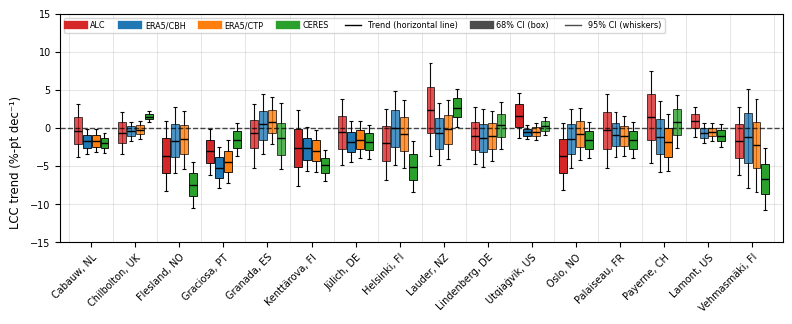

In [ ]:
from matplotlib.patches import Rectangle
import matplotlib.lines as mlines

suffix = ""
scale = 10 * 100  # % per decade

YLIMS = (-15, 15)  # default y-limits for the box-whisker plots

# Sort by daytime ALC trend value (ascending), excluding NaNs
alc_day_raw = ds_trends[f"alc_trend{suffix}"].dropna(dim="site")


def get_trend_and_ci(ds, name, sites_sel):
    trend = ds[f"{name}_trend{suffix}"].sel(site=sites_sel) * scale
    ci0 = (
        ds[f"{name}_trend_ci{suffix}"].sel(site=sites_sel).isel(sigma_level=0)
        * scale
    )  # box
    ci1 = (
        ds[f"{name}_trend_ci{suffix}"].sel(site=sites_sel).isel(sigma_level=1)
        * scale
    )  # whiskers
    return trend, ci0, ci1


trend_data_alc, ci0_alc, ci1_alc = get_trend_and_ci(
    ds_trends, "alc", analysis_sites
)
trend_data_era5, ci0_era5, ci1_era5 = get_trend_and_ci(
    ds_trends, "era5", analysis_sites
)
trend_data_era5_isccp, ci0_era5_isccp, ci1_era5_isccp = get_trend_and_ci(
    ds_trends, "era5_isccp_non_obscured", analysis_sites
)
trend_data_ceres, ci0_ceres, ci1_ceres = get_trend_and_ci(
    ds_trends, "ceres_adj", analysis_sites
)

if "YLIMS" not in globals():
    all_ci = [
        ci1_alc.values,
        ci1_era5.values,
        ci1_era5_isccp.values,
        ci1_ceres.values,
    ]
    y_min = min(np.nanmin(a) for a in all_ci)
    y_max = max(np.nanmax(a) for a in all_ci)
    YLIMS = (y_min - 0.5, y_max + 0.5)


def get_alpha(trend_val, ci_upper, ci_lower):
    return (
        1.0
        if (
            (trend_val > 0 and ci_lower > 0)
            or (trend_val < 0 and ci_upper < 0)
        )
        else 0.8
    )


def draw_custom_box(
    ax, x, trend, ci0_low, ci0_up, ci1_low, ci1_up, color, alpha=1.0, w=0.18
):
    # whiskers (sigma_level=1): vertical
    ax.vlines(
        x,
        ci1_low,
        ci1_up,
        color="black",
        lw=0.8,
        alpha=min(1, alpha * 1.2),
        zorder=1,
    )
    ax.hlines(
        [ci1_low, ci1_up],
        x - w * 0.25,
        x + w * 0.25,
        color="black",
        lw=0.8,
        alpha=min(1, alpha * 1.2),
        zorder=1,
    )

    # box (sigma_level=0): vertical
    rect = Rectangle(
        (x - w / 2, ci0_low),
        w,
        ci0_up - ci0_low,
        facecolor=color,
        edgecolor="black",
        lw=0.6,
        alpha=alpha,
        zorder=2,
    )
    ax.add_patch(rect)

    # trend estimate: horizontal line inside box
    ax.hlines(trend, x - w / 2, x + w / 2, color="black", lw=1.0, zorder=3)


fig, ax = plt.subplots(
    1,
    1,
    figsize=(figwidth, figwidth * 0.4),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

x_base = np.arange(len(analysis_sites))

offsets = {
    "ALC": -0.30,
    "ERA5/CBH": -0.10,
    "ERA5/CTP": 0.10,
    "CERES": 0.30,
}

colors = {
    "ALC": "tab:red",
    "ERA5/CBH": "tab:blue",
    "ERA5/CTP": "tab:orange",
    "CERES": "tab:green",
}

# Daytime panel
for i, s in enumerate(analysis_sites):
    a = get_alpha(
        trend_data_alc.sel(site=s).item(),
        ci0_alc.sel(site=s, bound="upper").item(),
        ci0_alc.sel(site=s, bound="lower").item(),
    )

    e = get_alpha(
        trend_data_era5.sel(site=s).item(),
        ci0_era5.sel(site=s, bound="upper").item(),
        ci0_era5.sel(site=s, bound="lower").item(),
    )

    ei = get_alpha(
        trend_data_era5_isccp.sel(site=s).item(),
        ci0_era5_isccp.sel(site=s, bound="upper").item(),
        ci0_era5_isccp.sel(site=s, bound="lower").item(),
    )

    m = get_alpha(
        trend_data_ceres.sel(site=s).item(),
        ci0_ceres.sel(site=s, bound="upper").item(),
        ci0_ceres.sel(site=s, bound="lower").item(),
    )

    draw_custom_box(
        ax,
        x_base[i] + offsets["ALC"],
        trend_data_alc.sel(site=s).item(),
        ci0_alc.sel(site=s, bound="lower").item(),
        ci0_alc.sel(site=s, bound="upper").item(),
        ci1_alc.sel(site=s, bound="lower").item(),
        ci1_alc.sel(site=s, bound="upper").item(),
        colors["ALC"],
        a,
    )

    draw_custom_box(
        ax,
        x_base[i] + offsets["ERA5/CBH"],
        trend_data_era5.sel(site=s).item(),
        ci0_era5.sel(site=s, bound="lower").item(),
        ci0_era5.sel(site=s, bound="upper").item(),
        ci1_era5.sel(site=s, bound="lower").item(),
        ci1_era5.sel(site=s, bound="upper").item(),
        colors["ERA5/CBH"],
        e,
    )

    draw_custom_box(
        ax,
        x_base[i] + offsets["ERA5/CTP"],
        trend_data_era5_isccp.sel(site=s).item(),
        ci0_era5_isccp.sel(site=s, bound="lower").item(),
        ci0_era5_isccp.sel(site=s, bound="upper").item(),
        ci1_era5_isccp.sel(site=s, bound="lower").item(),
        ci1_era5_isccp.sel(site=s, bound="upper").item(),
        colors["ERA5/CTP"],
        ei,
    )

    draw_custom_box(
        ax,
        x_base[i] + offsets["CERES"],
        trend_data_ceres.sel(site=s).item(),
        ci0_ceres.sel(site=s, bound="lower").item(),
        ci0_ceres.sel(site=s, bound="upper").item(),
        ci1_ceres.sel(site=s, bound="lower").item(),
        ci1_ceres.sel(site=s, bound="upper").item(),
        colors["CERES"],
        m,
    )


ax.axhline(0, color="black", linestyle="--", lw=1, alpha=0.7)
ax.grid(True, axis="y", alpha=0.3)
ax.set_axisbelow(True)
ax.set_xticks(np.arange(-0.5, len(analysis_sites), 1), minor=True)
ax.grid(True, axis="x", which="minor", color="0.85", lw=0.6, alpha=0.8)
ax.tick_params(axis="x", which="minor", length=0)
ax.set_ylim(YLIMS)
ax.set_xlim(-0.7, len(analysis_sites) - 0.3)


ax.set_xticks(x_base)
ax.set_xticklabels(
    [
        f"{sites.loc[s, 'humanReadableName']}, {sites.loc[s, 'countryCode']}"
        for s in analysis_sites
    ],
    rotation=45,
    fontsize=7,
    ha="right",
    rotation_mode="anchor",
)

fig.supylabel(r"LCC trend (%-pt dec⁻¹)")

legend_elements = [
    mlines.Line2D([0], [0], color=colors["ALC"], lw=6, label="ALC"),
    mlines.Line2D([0], [0], color=colors["ERA5/CBH"], lw=6, label="ERA5/CBH"),
    mlines.Line2D([0], [0], color=colors["ERA5/CTP"], lw=6, label="ERA5/CTP"),
    mlines.Line2D([0], [0], color=colors["CERES"], lw=6, label="CERES"),
    mlines.Line2D(
        [0], [0], color="black", lw=1, label="Trend (horizontal line)"
    ),
    mlines.Line2D([0], [0], color="k", lw=6, label="68% CI (box)", alpha=0.7),
    mlines.Line2D(
        [0],
        [0],
        color="black",
        lw=1,
        linestyle="-",
        label="95% CI (whiskers)",
        alpha=0.7,
    ),
]

ax.legend(handles=legend_elements, loc="upper left", fontsize="small", ncols=7)

fig.savefig(
    results_path
    / "alc_era5_era5_isccp_ceres_lcc_absolute_trends_box_whisker_full_diurnal.pdf",
    dpi=300,
)

plt.show()


In [ ]:
print("Theil-Sen trends:")
for site in analysis_sites:
    alc_trend = float(trend_data_alc.sel(site=site).item())
    era5_wmo_trend = float(trend_data_era5.sel(site=site).item())
    era5_isccp_trend = float(trend_data_era5_isccp.sel(site=site).item())
    ceres_trend = float(trend_data_ceres.sel(site=site).item())
    print(
        f"{site:<10}: ALC: {alc_trend:5.1f}, ERA5/WMO: {era5_wmo_trend:5.1f}, ERA5/CTP: {era5_isccp_trend:5.1f}, CERES: {ceres_trend:5.1f}"
    )

Theil-Sen trends:
cabauw    : ALC:  -0.4, ERA5/WMO:  -1.7, ERA5/CTP:  -1.6, CERES:  -1.9
chilbolton: ALC:  -0.6, ERA5/WMO:  -0.4, ERA5/CTP:  -0.2, CERES:   1.5
flesland  : ALC:  -3.7, ERA5/WMO:  -1.6, ERA5/CTP:  -1.5, CERES:  -7.4
graciosa  : ALC:  -3.0, ERA5/WMO:  -5.2, ERA5/CTP:  -4.4, CERES:  -1.5
granada   : ALC:  -0.7, ERA5/WMO:   0.5, ERA5/CTP:   0.9, CERES:  -1.3
kenttarova: ALC:  -2.5, ERA5/WMO:  -2.7, ERA5/CTP:  -3.0, CERES:  -4.9
juelich   : ALC:  -0.5, ERA5/WMO:  -1.8, ERA5/CTP:  -1.5, CERES:  -1.8
kumpula   : ALC:  -2.0, ERA5/WMO:  -0.0, ERA5/CTP:  -0.8, CERES:  -5.1
lauder    : ALC:   2.4, ERA5/WMO:  -0.6, ERA5/CTP:  -0.2, CERES:   2.7
lindenberg: ALC:  -1.0, ERA5/WMO:  -1.3, ERA5/CTP:  -1.0, CERES:   0.4
nsa       : ALC:   1.6, ERA5/WMO:  -0.5, ERA5/CTP:  -0.4, CERES:   0.3
oslo      : ALC:  -3.7, ERA5/WMO:  -1.4, ERA5/CTP:  -0.8, CERES:  -1.6
palaiseau : ALC:  -0.3, ERA5/WMO:  -0.8, ERA5/CTP:  -1.0, CERES:  -1.6
payerne   : ALC:   1.4, ERA5/WMO:  -1.1, ERA5/CTP:  -1.9, C

In [ ]:
print("Trend CIs:")
for site in analysis_sites:
    alc_lower = float(ci0_alc.sel(site=site, bound="lower").item())
    era5_wmo_lower = float(ci0_era5.sel(site=site, bound="lower").item())
    era5_isccp_lower = float(
        ci0_era5_isccp.sel(site=site, bound="lower").item()
    )
    ceres_lower = float(ci0_ceres.sel(site=site, bound="lower").item())
    alc_upper = float(ci0_alc.sel(site=site, bound="upper").item())
    era5_wmo_upper = float(ci0_era5.sel(site=site, bound="upper").item())
    era5_isccp_upper = float(
        ci0_era5_isccp.sel(site=site, bound="upper").item()
    )
    ceres_upper = float(ci0_ceres.sel(site=site, bound="upper").item())
    print(
        f"{site:<10}: ALC: [{alc_lower:5.1f}, {alc_upper:5.1f}], ERA5/WMO: [{era5_wmo_lower:5.1f}, {era5_wmo_upper:5.1f}], ERA5/CTP: [{era5_isccp_lower:5.1f}, {era5_isccp_upper:5.1f}], CERES: [{ceres_lower:5.1f}, {ceres_upper:5.1f}]"
    )

Trend CIs:
cabauw    : ALC: [ -2.1,   1.4], ERA5/WMO: [ -2.6,  -0.9], ERA5/CTP: [ -2.4,  -0.9], CERES: [ -2.6,  -1.3]
chilbolton: ALC: [ -2.0,   0.8], ERA5/WMO: [ -1.0,   0.2], ERA5/CTP: [ -0.8,   0.4], CERES: [  1.2,   1.9]
flesland  : ALC: [ -5.9,  -1.3], ERA5/WMO: [ -3.7,   0.5], ERA5/CTP: [ -3.4,   0.4], CERES: [ -8.9,  -5.9]
graciosa  : ALC: [ -4.6,  -1.5], ERA5/WMO: [ -6.5,  -3.8], ERA5/CTP: [ -5.8,  -3.0], CERES: [ -2.6,  -0.4]
granada   : ALC: [ -2.6,   1.0], ERA5/WMO: [ -1.6,   2.3], ERA5/CTP: [ -0.7,   2.3], CERES: [ -3.5,   0.7]
kenttarova: ALC: [ -5.0,  -0.1], ERA5/WMO: [ -4.1,  -1.2], ERA5/CTP: [ -4.3,  -1.6], CERES: [ -5.9,  -3.9]
juelich   : ALC: [ -2.7,   1.7], ERA5/WMO: [ -3.1,  -0.4], ERA5/CTP: [ -2.7,  -0.3], CERES: [ -2.9,  -0.7]
kumpula   : ALC: [ -4.3,   0.3], ERA5/WMO: [ -2.4,   2.4], ERA5/CTP: [ -3.0,   1.4], CERES: [ -6.8,  -3.4]
lauder    : ALC: [ -0.6,   5.4], ERA5/WMO: [ -2.7,   1.3], ERA5/CTP: [ -2.1,   1.8], CERES: [  1.4,   3.9]
lindenberg: ALC: [ -2.9,  

##### Daytime-nighttime

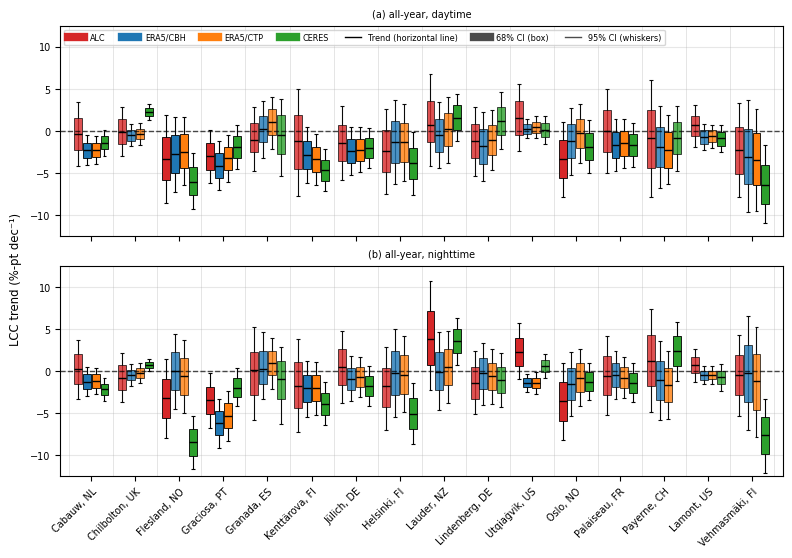

In [ ]:
suffix = ""
scale = 10 * 100  # % per decade

YLIMS = (-12.5, 12.5)  # default y-limits for the box-whisker plots

# Sort by daytime ALC trend value (ascending), excluding NaNs
alc_day_raw = ds_trends_daytime[f"alc_trend{suffix}"].dropna(dim="site")


def get_trend_and_ci(ds, name, sites_sel):
    trend = ds[f"{name}_trend{suffix}"].sel(site=sites_sel) * scale
    ci0 = (
        ds[f"{name}_trend_ci{suffix}"].sel(site=sites_sel).isel(sigma_level=0)
        * scale
    )  # box
    ci1 = (
        ds[f"{name}_trend_ci{suffix}"].sel(site=sites_sel).isel(sigma_level=1)
        * scale
    )  # whiskers
    return trend, ci0, ci1


trend_data_alc_day, ci0_alc_day, ci1_alc_day = get_trend_and_ci(
    ds_trends_daytime, "alc", analysis_sites
)
trend_data_era5_day, ci0_era5_day, ci1_era5_day = get_trend_and_ci(
    ds_trends_daytime, "era5", analysis_sites
)
trend_data_era5_isccp_day, ci0_era5_isccp_day, ci1_era5_isccp_day = (
    get_trend_and_ci(
        ds_trends_daytime, "era5_isccp_non_obscured", analysis_sites
    )
)
trend_data_ceres_day, ci0_ceres_day, ci1_ceres_day = get_trend_and_ci(
    ds_trends_daytime, "ceres_adj", analysis_sites
)

trend_data_alc_night, ci0_alc_night, ci1_alc_night = get_trend_and_ci(
    ds_trends_nighttime, "alc", analysis_sites
)
trend_data_era5_night, ci0_era5_night, ci1_era5_night = get_trend_and_ci(
    ds_trends_nighttime, "era5", analysis_sites
)
trend_data_era5_isccp_night, ci0_era5_isccp_night, ci1_era5_isccp_night = (
    get_trend_and_ci(
        ds_trends_nighttime, "era5_isccp_non_obscured", analysis_sites
    )
)
trend_data_ceres_night, ci0_ceres_night, ci1_ceres_night = get_trend_and_ci(
    ds_trends_nighttime, "ceres_adj", analysis_sites
)

if "YLIMS" not in globals():
    all_ci = [
        ci1_alc_day.values,
        ci1_era5_day.values,
        ci1_era5_isccp_day.values,
        ci1_ceres_day.values,
        ci1_alc_night.values,
        ci1_era5_night.values,
        ci1_era5_isccp_night.values,
        ci1_ceres_night.values,
    ]
    y_min = min(np.nanmin(a) for a in all_ci)
    y_max = max(np.nanmax(a) for a in all_ci)
    YLIMS = (y_min - 0.5, y_max + 0.5)


def get_alpha(trend_val, ci_upper, ci_lower):
    return (
        1.0
        if (
            (trend_val > 0 and ci_lower > 0)
            or (trend_val < 0 and ci_upper < 0)
        )
        else 0.8
    )


def draw_custom_box(
    ax, x, trend, ci0_low, ci0_up, ci1_low, ci1_up, color, alpha=1.0, w=0.18
):
    # whiskers (sigma_level=1): vertical
    ax.vlines(
        x,
        ci1_low,
        ci1_up,
        color="black",
        lw=0.8,
        alpha=min(1, alpha * 1.2),
        zorder=1,
    )
    ax.hlines(
        [ci1_low, ci1_up],
        x - w * 0.25,
        x + w * 0.25,
        color="black",
        lw=0.8,
        alpha=min(1, alpha * 1.2),
        zorder=1,
    )

    # box (sigma_level=0): vertical
    rect = Rectangle(
        (x - w / 2, ci0_low),
        w,
        ci0_up - ci0_low,
        facecolor=color,
        edgecolor="black",
        lw=0.6,
        alpha=alpha,
        zorder=2,
    )
    ax.add_patch(rect)

    # trend estimate: horizontal line inside box
    ax.hlines(trend, x - w / 2, x + w / 2, color="black", lw=1.0, zorder=3)


fig, (ax1, ax2) = plt.subplots(
    2,
    1,
    figsize=(figwidth, figwidth * 0.7),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

x_base = np.arange(len(analysis_sites))

offsets = {
    "ALC": -0.30,
    "ERA5/CBH": -0.10,
    "ERA5/CTP": 0.10,
    "CERES": 0.30,
}

colors = {
    "ALC": "tab:red",
    "ERA5/CBH": "tab:blue",
    "ERA5/CTP": "tab:orange",
    "CERES": "tab:green",
}

# Daytime panel
for i, s in enumerate(analysis_sites):
    a = get_alpha(
        trend_data_alc_day.sel(site=s).item(),
        ci0_alc_day.sel(site=s, bound="upper").item(),
        ci0_alc_day.sel(site=s, bound="lower").item(),
    )

    e = get_alpha(
        trend_data_era5_day.sel(site=s).item(),
        ci0_era5_day.sel(site=s, bound="upper").item(),
        ci0_era5_day.sel(site=s, bound="lower").item(),
    )

    ei = get_alpha(
        trend_data_era5_isccp_day.sel(site=s).item(),
        ci0_era5_isccp_day.sel(site=s, bound="upper").item(),
        ci0_era5_isccp_day.sel(site=s, bound="lower").item(),
    )

    m = get_alpha(
        trend_data_ceres_day.sel(site=s).item(),
        ci0_ceres_day.sel(site=s, bound="upper").item(),
        ci0_ceres_day.sel(site=s, bound="lower").item(),
    )

    draw_custom_box(
        ax1,
        x_base[i] + offsets["ALC"],
        trend_data_alc_day.sel(site=s).item(),
        ci0_alc_day.sel(site=s, bound="lower").item(),
        ci0_alc_day.sel(site=s, bound="upper").item(),
        ci1_alc_day.sel(site=s, bound="lower").item(),
        ci1_alc_day.sel(site=s, bound="upper").item(),
        colors["ALC"],
        a,
    )

    draw_custom_box(
        ax1,
        x_base[i] + offsets["ERA5/CBH"],
        trend_data_era5_day.sel(site=s).item(),
        ci0_era5_day.sel(site=s, bound="lower").item(),
        ci0_era5_day.sel(site=s, bound="upper").item(),
        ci1_era5_day.sel(site=s, bound="lower").item(),
        ci1_era5_day.sel(site=s, bound="upper").item(),
        colors["ERA5/CBH"],
        e,
    )

    draw_custom_box(
        ax1,
        x_base[i] + offsets["ERA5/CTP"],
        trend_data_era5_isccp_day.sel(site=s).item(),
        ci0_era5_isccp_day.sel(site=s, bound="lower").item(),
        ci0_era5_isccp_day.sel(site=s, bound="upper").item(),
        ci1_era5_isccp_day.sel(site=s, bound="lower").item(),
        ci1_era5_isccp_day.sel(site=s, bound="upper").item(),
        colors["ERA5/CTP"],
        ei,
    )

    draw_custom_box(
        ax1,
        x_base[i] + offsets["CERES"],
        trend_data_ceres_day.sel(site=s).item(),
        ci0_ceres_day.sel(site=s, bound="lower").item(),
        ci0_ceres_day.sel(site=s, bound="upper").item(),
        ci1_ceres_day.sel(site=s, bound="lower").item(),
        ci1_ceres_day.sel(site=s, bound="upper").item(),
        colors["CERES"],
        m,
    )


# Nighttime panel

for i, s in enumerate(analysis_sites):
    a = get_alpha(
        trend_data_alc_night.sel(site=s).item(),
        ci0_alc_night.sel(site=s, bound="upper").item(),
        ci0_alc_night.sel(site=s, bound="lower").item(),
    )

    e = get_alpha(
        trend_data_era5_night.sel(site=s).item(),
        ci0_era5_night.sel(site=s, bound="upper").item(),
        ci0_era5_night.sel(site=s, bound="lower").item(),
    )

    ei = get_alpha(
        trend_data_era5_isccp_night.sel(site=s).item(),
        ci0_era5_isccp_night.sel(site=s, bound="upper").item(),
        ci0_era5_isccp_night.sel(site=s, bound="lower").item(),
    )

    m = get_alpha(
        trend_data_ceres_night.sel(site=s).item(),
        ci0_ceres_night.sel(site=s, bound="upper").item(),
        ci0_ceres_night.sel(site=s, bound="lower").item(),
    )

    draw_custom_box(
        ax2,
        x_base[i] + offsets["ALC"],
        trend_data_alc_night.sel(site=s).item(),
        ci0_alc_night.sel(site=s, bound="lower").item(),
        ci0_alc_night.sel(site=s, bound="upper").item(),
        ci1_alc_night.sel(site=s, bound="lower").item(),
        ci1_alc_night.sel(site=s, bound="upper").item(),
        colors["ALC"],
        a,
    )

    draw_custom_box(
        ax2,
        x_base[i] + offsets["ERA5/CBH"],
        trend_data_era5_night.sel(site=s).item(),
        ci0_era5_night.sel(site=s, bound="lower").item(),
        ci0_era5_night.sel(site=s, bound="upper").item(),
        ci1_era5_night.sel(site=s, bound="lower").item(),
        ci1_era5_night.sel(site=s, bound="upper").item(),
        colors["ERA5/CBH"],
        e,
    )

    draw_custom_box(
        ax2,
        x_base[i] + offsets["ERA5/CTP"],
        trend_data_era5_isccp_night.sel(site=s).item(),
        ci0_era5_isccp_night.sel(site=s, bound="lower").item(),
        ci0_era5_isccp_night.sel(site=s, bound="upper").item(),
        ci1_era5_isccp_night.sel(site=s, bound="lower").item(),
        ci1_era5_isccp_night.sel(site=s, bound="upper").item(),
        colors["ERA5/CTP"],
        ei,
    )

    draw_custom_box(
        ax2,
        x_base[i] + offsets["CERES"],
        trend_data_ceres_night.sel(site=s).item(),
        ci0_ceres_night.sel(site=s, bound="lower").item(),
        ci0_ceres_night.sel(site=s, bound="upper").item(),
        ci1_ceres_night.sel(site=s, bound="lower").item(),
        ci1_ceres_night.sel(site=s, bound="upper").item(),
        colors["CERES"],
        m,
    )


for ax in (ax1, ax2):
    ax.axhline(0, color="black", linestyle="--", lw=1, alpha=0.7)
    ax.grid(True, axis="y", alpha=0.3)
    ax.set_axisbelow(True)
    ax.set_xticks(np.arange(-0.5, len(analysis_sites), 1), minor=True)
    ax.grid(True, axis="x", which="minor", color="0.85", lw=0.6, alpha=0.8)
    ax.tick_params(axis="x", which="minor", length=0)
    ax.set_ylim(YLIMS)
    ax.set_xlim(-0.7, len(analysis_sites) - 0.3)


ax1.set_title("(a) all-year, daytime", fontsize="medium")
ax2.set_title("(b) all-year, nighttime", fontsize="medium")

ax2.set_xticks(x_base)
ax2.set_xticklabels(
    [
        f"{sites.loc[s, 'humanReadableName']}, {sites.loc[s, 'countryCode']}"
        for s in analysis_sites
    ],
    rotation=45,
    fontsize=7,
    ha="right",
    rotation_mode="anchor",
)

fig.supylabel(r"LCC trend (%-pt dec⁻¹)")

legend_elements = [
    mlines.Line2D([0], [0], color=colors["ALC"], lw=6, label="ALC"),
    mlines.Line2D([0], [0], color=colors["ERA5/CBH"], lw=6, label="ERA5/CBH"),
    mlines.Line2D([0], [0], color=colors["ERA5/CTP"], lw=6, label="ERA5/CTP"),
    mlines.Line2D([0], [0], color=colors["CERES"], lw=6, label="CERES"),
    mlines.Line2D(
        [0], [0], color="black", lw=1, label="Trend (horizontal line)"
    ),
    mlines.Line2D([0], [0], color="k", lw=6, label="68% CI (box)", alpha=0.7),
    mlines.Line2D(
        [0],
        [0],
        color="black",
        lw=1,
        linestyle="-",
        label="95% CI (whiskers)",
        alpha=0.7,
    ),
]

ax1.legend(
    handles=legend_elements, loc="upper left", fontsize="small", ncols=7
)

fig.savefig(
    results_path
    / "alc_era5_era5_isccp_ceres_lcc_absolute_trends_box_whisker_day_night.pdf",
    dpi=300,
)

plt.show()

#### Crossplot

##### Daytime

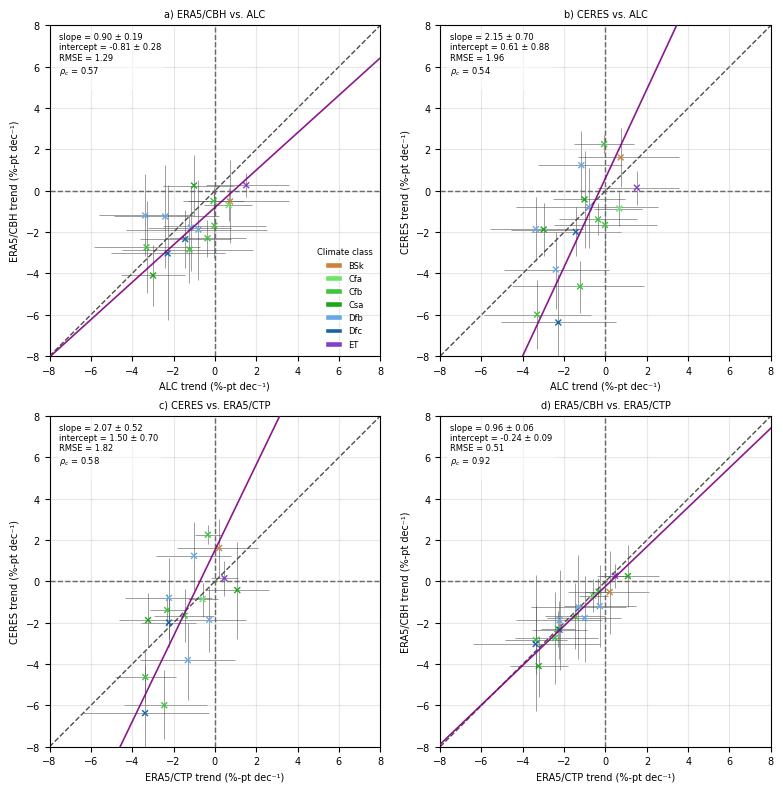

In [ ]:
from matplotlib.patches import Patch

suffix = ""
scale = 10 * 100  # % per decade
axes_limits = (-8, 8)

pairwise_series = {
    "ALC": {
        "trend": ds_trends_daytime[f"alc_trend{suffix}"] * scale,
        "ci68": ds_trends_daytime[f"alc_trend_ci{suffix}"].isel(sigma_level=0)
        * scale,
        "color": "tab:red",
    },
    "ERA5/CBH": {
        "trend": ds_trends_daytime[f"era5_trend{suffix}"] * scale,
        "ci68": ds_trends_daytime[f"era5_trend_ci{suffix}"].isel(sigma_level=0)
        * scale,
        "color": "tab:blue",
    },
    "ERA5/CTP": {
        "trend": ds_trends_daytime[f"era5_isccp_non_obscured_trend{suffix}"]
        * scale,
        "ci68": ds_trends_daytime[
            f"era5_isccp_non_obscured_trend_ci{suffix}"
        ].isel(sigma_level=0)
        * scale,
        "color": "tab:orange",
    },
    "CERES": {
        "trend": ds_trends_daytime[f"ceres_adj_trend{suffix}"] * scale,
        "ci68": ds_trends_daytime[f"ceres_adj_trend_ci{suffix}"].isel(
            sigma_level=0
        )
        * scale,
        "color": "tab:green",
    },
}

all_trend_values = np.concatenate(
    [series["trend"].values.ravel() for series in pairwise_series.values()]
)
finite_trend_values = all_trend_values[np.isfinite(all_trend_values)]
max_abs_trend = np.max(np.abs(finite_trend_values))
max_trend = np.max(finite_trend_values)
min_trend = np.min(finite_trend_values)
axis_margin = 0.1 * max_abs_trend
max_limit = max_trend + axis_margin
min_limit = min_trend - axis_margin

pair_names = [
    ("ALC", "ERA5/CBH"),
    ("ALC", "CERES"),
    ("ERA5/CTP", "CERES"),
    ("ERA5/CTP", "ERA5/CBH"),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(figwidth, figwidth),
    constrained_layout=True,
    sharex=False,
    sharey=False,
)

for idx, (ax, (x_name, y_name)) in enumerate(zip(axes.flat, pair_names)):
    x_trend = pairwise_series[x_name]["trend"]
    y_trend = pairwise_series[y_name]["trend"]

    valid_mask = (~np.isnan(x_trend)) & (~np.isnan(y_trend))
    sites_sel = x_trend.site.where(valid_mask, drop=True).values

    x_vals = x_trend.sel(site=sites_sel)
    y_vals = y_trend.sel(site=sites_sel)
    x_ci = pairwise_series[x_name]["ci68"].sel(site=sites_sel)
    y_ci = pairwise_series[y_name]["ci68"].sel(site=sites_sel)

    latitudes = [np.abs(sites.loc[site].geometry.y) for site in sites_sel]

    x_lower = x_ci.sel(bound="lower").values
    x_upper = x_ci.sel(bound="upper").values
    y_lower = y_ci.sel(bound="lower").values
    y_upper = y_ci.sel(bound="upper").values

    xerr = np.vstack([x_vals.values - x_lower, x_upper - x_vals.values])
    yerr = np.vstack([y_vals.values - y_lower, y_upper - y_vals.values])

    ax.errorbar(
        x_vals.values,
        y_vals.values,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="0.3",
        elinewidth=0.7,
        alpha=0.55,
        zorder=1,
    )
    lat_bins = [35, 45, 55, 65, 75]
    categorical_colors = plt.cm.tab10(np.linspace(0, 0.35, len(lat_bins) - 1))

    point_colors = []
    for lat in latitudes:
        for i, (lo, hi) in enumerate(zip(lat_bins[:-1], lat_bins[1:])):
            if lo <= lat < hi:
                point_colors.append(categorical_colors[i])
                break
        else:
            point_colors.append("gray")

    ax.scatter(
        x_vals.values,
        y_vals.values,
        marker="x",
        s=18,
        c=climate_colors,
        linewidth=1,
        zorder=2,
    )

    if idx == 0:
        legend_handles = [
            Patch(
                facecolor=climate_color_map[climate],
                edgecolor="white",
                label=climate,
            )
            for climate in climate_color_map
        ]

        ax.legend(
            handles=legend_handles,
            title="Climate class",
            loc="lower right",
            frameon=False,
            fontsize=6,
            title_fontsize=6,
        )

    # --- ODR on CI midpoints ---
    x_mid = 0.5 * (x_lower + x_upper)
    y_mid = 0.5 * (y_lower + y_upper)
    sx = x_upper - x_lower
    sy = y_upper - y_lower

    odr_mask = (
        np.isfinite(x_mid)
        & np.isfinite(y_mid)
        & np.isfinite(sx)
        & np.isfinite(sy)
        & (sx > 0)
        & (sy > 0)
    )

    odr_slope, odr_intercept = np.nan, np.nan
    odr_slope_err, odr_intercept_err = np.nan, np.nan

    if np.sum(odr_mask) >= 2:

        def linear_model(beta, x):
            return beta[0] * x + beta[1]

        model = odr.Model(linear_model)
        data = odr.RealData(
            x_mid[odr_mask], y_mid[odr_mask], sx=sx[odr_mask], sy=sy[odr_mask]
        )

        p = np.polyfit(x_mid[odr_mask], y_mid[odr_mask], 1)
        odr_fit = odr.ODR(data, model, beta0=[p[0], p[1]])
        out = odr_fit.run()

        odr_slope, odr_intercept = out.beta
        odr_slope_err, odr_intercept_err = out.sd_beta

        xx = np.array([axes_limits[0], axes_limits[1]])
        yy = odr_slope * xx + odr_intercept
        ax.plot(xx, yy, color="purple", linewidth=1.2, alpha=0.9, zorder=3)

    ax.set_xlim(axes_limits)
    ax.set_ylim(axes_limits)
    ax.set_xticks(np.sort(np.unique(np.append(ax.get_xticks(), 0.0))))
    ax.set_yticks(np.sort(np.unique(np.append(ax.get_yticks(), 0.0))))

    # 1:1 line
    ax.plot(
        axes_limits,
        axes_limits,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        zorder=0,
    )

    residuals = y_vals.values - x_vals.values
    rmse = np.sqrt(np.mean(residuals**2))
    correlation = (
        np.corrcoef(x_vals.values, y_vals.values)[0, 1]
        if len(x_vals) > 1
        else np.nan
    )
    r_squared = correlation**2 if np.isfinite(correlation) else np.nan
    finite_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_f = x_vals[finite_mask]
    y_f = y_vals[finite_mask]

    denom = sx**2 + sy**2
    chi_mask = np.isfinite(residuals) & np.isfinite(denom) & (denom > 0)
    chi_sq = (
        np.sum((residuals[chi_mask] ** 2) / denom[chi_mask])
        if np.any(chi_mask)
        else np.nan
    )
    chi_reduced = chi_sq / (np.sum(chi_mask) - 2) if np.sum(chi_mask) > 0 else np.nan

    xv = x_vals.values
    yv = y_vals.values
    finite_xy = np.isfinite(xv) & np.isfinite(yv)

    mbe = float(np.nanmean(residuals))
    mbe_err = (
        np.std(residuals) / np.sqrt(np.sum(finite_xy))
        if np.sum(finite_xy) > 0
        else np.nan
    )
    
    concordance_cc = (2.0 * np.cov(x_f, y_f, ddof=1)[0, 1]) / (
        np.var(x_f, ddof=1)
        + np.var(y_f, ddof=1)
        + (np.mean(x_f) - np.mean(y_f)) ** 2
    )

    ax.text(
        0.03,
        0.98,
        (
            f"slope = {odr_slope:.2f} ± {odr_slope_err:.2f}\n"
            f"intercept = {odr_intercept:.2f} ± {odr_intercept_err:.2f}\n"
            f"RMSE = {rmse:.2f}\n"
            f"$\\rho_c$ = {concordance_cc:.2f}\n"
        ),
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=6,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.5,
            "pad": 2.0,
        },
    )

    ax.axhline(0, color="black", linestyle="--", lw=1, alpha=0.7, zorder=0)
    ax.axvline(0, color="black", linestyle="--", lw=1, alpha=0.7, zorder=0)
    ax.set_xlim(axes_limits)
    ax.set_ylim(axes_limits)
    ax.set_title(f"{chr(97 + idx)}) {y_name} vs. {x_name}", fontsize="medium")
    ax.set_xlabel(
        f"{x_name} trend (%-pt dec⁻¹)",
    )
    ax.set_ylabel(f"{y_name} trend (%-pt dec⁻¹)")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

fig.savefig(
    results_path
    / "alc_era5_era5_isccp_ceres_lcc_pairwise_scatter_daytime.pdf",
    dpi=300
)
plt.show()

##### Nighttime

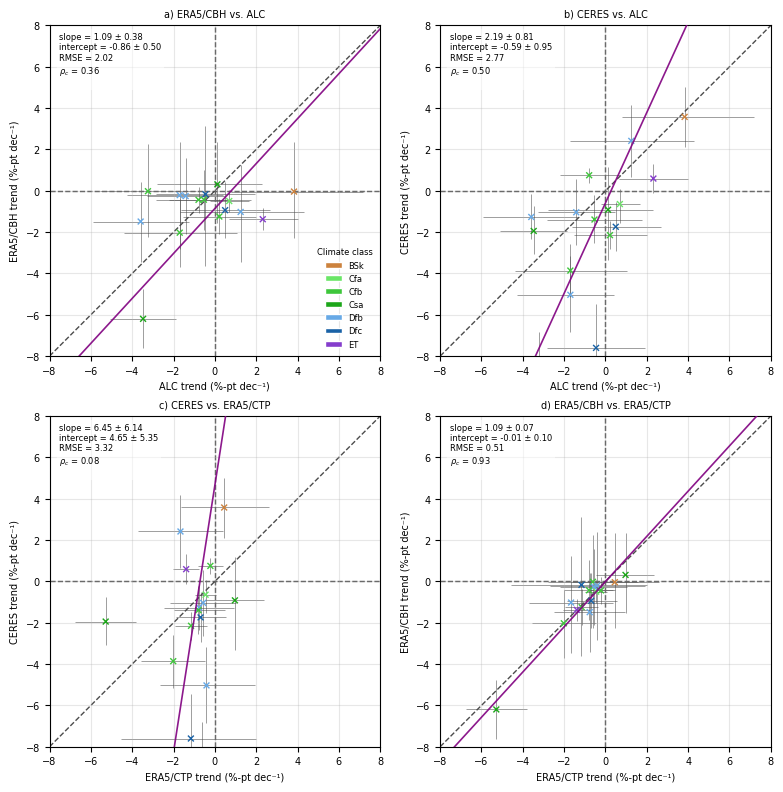

In [ ]:
pairwise_series = {
    "ALC": {
        "trend": ds_trends_nighttime[f"alc_trend{suffix}"] * scale,
        "ci68": ds_trends_nighttime[f"alc_trend_ci{suffix}"].isel(
            sigma_level=0
        )
        * scale,
        "color": "tab:red",
    },
    "ERA5/CBH": {
        "trend": ds_trends_nighttime[f"era5_trend{suffix}"] * scale,
        "ci68": ds_trends_nighttime[f"era5_trend_ci{suffix}"].isel(
            sigma_level=0
        )
        * scale,
        "color": "tab:blue",
    },
    "ERA5/CTP": {
        "trend": ds_trends_nighttime[f"era5_isccp_non_obscured_trend{suffix}"]
        * scale,
        "ci68": ds_trends_nighttime[
            f"era5_isccp_non_obscured_trend_ci{suffix}"
        ].isel(sigma_level=0)
        * scale,
        "color": "tab:orange",
    },
    "CERES": {
        "trend": ds_trends_nighttime[f"ceres_adj_trend{suffix}"] * scale,
        "ci68": ds_trends_nighttime[f"ceres_adj_trend_ci{suffix}"].isel(
            sigma_level=0
        )
        * scale,
        "color": "tab:green",
    },
}

all_trend_values = np.concatenate(
    [series["trend"].values.ravel() for series in pairwise_series.values()]
)
finite_trend_values = all_trend_values[np.isfinite(all_trend_values)]
max_abs_trend = np.max(np.abs(finite_trend_values))
max_trend = np.max(finite_trend_values)
min_trend = np.min(finite_trend_values)
axis_margin = 0.1 * max_abs_trend
max_limit = max_trend + axis_margin
min_limit = min_trend - axis_margin

pair_names = [
    ("ALC", "ERA5/CBH"),
    ("ALC", "CERES"),
    ("ERA5/CTP", "CERES"),
    ("ERA5/CTP", "ERA5/CBH"),
]

fig, axes = plt.subplots(
    2,
    2,
    figsize=(figwidth, figwidth),
    constrained_layout=True,
    sharex=False,
    sharey=False,
)

for idx, (ax, (x_name, y_name)) in enumerate(zip(axes.flat, pair_names)):
    x_trend = pairwise_series[x_name]["trend"]
    y_trend = pairwise_series[y_name]["trend"]

    valid_mask = (~np.isnan(x_trend)) & (~np.isnan(y_trend))
    sites_sel = x_trend.site.where(valid_mask, drop=True).values

    x_vals = x_trend.sel(site=sites_sel)
    y_vals = y_trend.sel(site=sites_sel)
    x_ci = pairwise_series[x_name]["ci68"].sel(site=sites_sel)
    y_ci = pairwise_series[y_name]["ci68"].sel(site=sites_sel)

    latitudes = [np.abs(sites.loc[site].geometry.y) for site in sites_sel]

    x_lower = x_ci.sel(bound="lower").values
    x_upper = x_ci.sel(bound="upper").values
    y_lower = y_ci.sel(bound="lower").values
    y_upper = y_ci.sel(bound="upper").values

    xerr = np.vstack([x_vals.values - x_lower, x_upper - x_vals.values])
    yerr = np.vstack([y_vals.values - y_lower, y_upper - y_vals.values])

    ax.errorbar(
        x_vals.values,
        y_vals.values,
        xerr=xerr,
        yerr=yerr,
        fmt="none",
        ecolor="0.3",
        elinewidth=0.7,
        alpha=0.55,
        zorder=1,
    )
    lat_bins = [35, 45, 55, 65, 75]
    categorical_colors = plt.cm.tab10(np.linspace(0, 0.35, len(lat_bins) - 1))

    point_colors = []
    for lat in latitudes:
        for i, (lo, hi) in enumerate(zip(lat_bins[:-1], lat_bins[1:])):
            if lo <= lat < hi:
                point_colors.append(categorical_colors[i])
                break
        else:
            point_colors.append("gray")

    ax.scatter(
        x_vals.values,
        y_vals.values,
        marker="x",
        s=18,
        c=climate_colors,
        linewidth=1,
        zorder=2,
    )

    if idx == 0:
        legend_handles = [
            Patch(
                facecolor=climate_color_map[climate],
                edgecolor="white",
                label=climate,
            )
            for climate in climate_color_map
        ]

        ax.legend(
            handles=legend_handles,
            title="Climate class",
            loc="lower right",
            frameon=False,
            fontsize=6,
            title_fontsize=6,
        )

    # --- ODR on CI midpoints ---
    x_mid = 0.5 * (x_lower + x_upper)
    y_mid = 0.5 * (y_lower + y_upper)
    sx = x_upper - x_lower
    sy = y_upper - y_lower

    odr_mask = (
        np.isfinite(x_mid)
        & np.isfinite(y_mid)
        & np.isfinite(sx)
        & np.isfinite(sy)
        & (sx > 0)
        & (sy > 0)
    )

    odr_slope, odr_intercept = np.nan, np.nan
    odr_slope_err, odr_intercept_err = np.nan, np.nan

    if np.sum(odr_mask) >= 2:

        def linear_model(beta, x):
            return beta[0] * x + beta[1]

        model = odr.Model(linear_model)
        data = odr.RealData(
            x_mid[odr_mask], y_mid[odr_mask], sx=sx[odr_mask], sy=sy[odr_mask]
        )

        p = np.polyfit(x_mid[odr_mask], y_mid[odr_mask], 1)
        odr_fit = odr.ODR(data, model, beta0=[p[0], p[1]])
        out = odr_fit.run()

        odr_slope, odr_intercept = out.beta
        odr_slope_err, odr_intercept_err = out.sd_beta

        xx = np.array([axes_limits[0], axes_limits[1]])
        yy = odr_slope * xx + odr_intercept
        ax.plot(xx, yy, color="purple", linewidth=1.2, alpha=0.9, zorder=3)

    ax.set_xlim(axes_limits)
    ax.set_ylim(axes_limits)
    ax.set_xticks(np.sort(np.unique(np.append(ax.get_xticks(), 0.0))))
    ax.set_yticks(np.sort(np.unique(np.append(ax.get_yticks(), 0.0))))

    # 1:1 line
    ax.plot(
        axes_limits,
        axes_limits,
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        zorder=0,
    )

    residuals = y_vals.values - x_vals.values
    rmse = np.sqrt(np.mean(residuals**2))
    correlation = (
        np.corrcoef(x_vals.values, y_vals.values)[0, 1]
        if len(x_vals) > 1
        else np.nan
    )
    r_squared = correlation**2 if np.isfinite(correlation) else np.nan
    finite_mask = np.isfinite(x_vals) & np.isfinite(y_vals)
    x_f = x_vals[finite_mask]
    y_f = y_vals[finite_mask]

    denom = sx**2 + sy**2
    chi_mask = np.isfinite(residuals) & np.isfinite(denom) & (denom > 0)
    chi_sq = (
        np.sum((residuals[chi_mask] ** 2) / denom[chi_mask])
        if np.any(chi_mask)
        else np.nan
    )
    chi_reduced = chi_sq / (np.sum(chi_mask) - 2) if np.sum(chi_mask) > 0 else np.nan

    xv = x_vals.values
    yv = y_vals.values
    finite_xy = np.isfinite(xv) & np.isfinite(yv)

    mbe = float(np.nanmean(residuals))
    mbe_err = (
        np.std(residuals) / np.sqrt(np.sum(finite_xy))
        if np.sum(finite_xy) > 0
        else np.nan
    )
    
    concordance_cc = (2.0 * np.cov(x_f, y_f, ddof=1)[0, 1]) / (
        np.var(x_f, ddof=1)
        + np.var(y_f, ddof=1)
        + (np.mean(x_f) - np.mean(y_f)) ** 2
    )

    ax.text(
        0.03,
        0.98,
        (
            f"slope = {odr_slope:.2f} ± {odr_slope_err:.2f}\n"
            f"intercept = {odr_intercept:.2f} ± {odr_intercept_err:.2f}\n"
            f"RMSE = {rmse:.2f}\n"
            f"$\\rho_c$ = {concordance_cc:.2f}\n"
        ),
        transform=ax.transAxes,
        va="top",
        ha="left",
        fontsize=6,
        bbox={
            "facecolor": "white",
            "edgecolor": "none",
            "alpha": 0.5,
            "pad": 2.0,
        },
    )

    ax.axhline(0, color="black", linestyle="--", lw=1, alpha=0.7, zorder=0)
    ax.axvline(0, color="black", linestyle="--", lw=1, alpha=0.7, zorder=0)
    ax.set_xlim(axes_limits)
    ax.set_ylim(axes_limits)
    ax.set_title(f"{chr(97 + idx)}) {y_name} vs. {x_name}", fontsize="medium")
    ax.set_xlabel(
        f"{x_name} trend (%-pt dec⁻¹)",
    )
    ax.set_ylabel(f"{y_name} trend (%-pt dec⁻¹)")
    ax.grid(True, alpha=0.3)
    ax.set_aspect("equal", adjustable="box")

fig.savefig(
    results_path
    / "alc_era5_era5_isccp_ceres_lcc_pairwise_scatter_nighttime.pdf",
    dpi=300,
)
plt.show()

#### Numeric summary

##### Full diurnal

In [ ]:
suffix = ""
scale = 10 * 100  # % per decade

variables = {
    "ALC": "alc",
    "ERA5/CBH": "era5",
    "ERA5/CTP": "era5_isccp_non_obscured",
    "CERES": "ceres_adj",
}

summary_by_dataset = {}


for var_label, var_prefix in variables.items():
    print(f"\n  {var_label}:")
    trend = (
        ds_trends[f"{var_prefix}_trend{suffix}"].sel(site=analysis_sites)
        * scale
    )
    ci68 = (
        ds_trends[f"{var_prefix}_trend_ci{suffix}"]
        .sel(site=analysis_sites)
        .isel(sigma_level=0)
        * scale
    )
    ci95 = (
        ds_trends[f"{var_prefix}_trend_ci{suffix}"]
        .sel(site=analysis_sites)
        .isel(sigma_level=1)
        * scale
    )

    for site in analysis_sites:
        t = float(trend.sel(site=site).values)
        lo68 = float(ci68.sel(site=site, bound="lower").values)
        hi68 = float(ci68.sel(site=site, bound="upper").values)
        lo95 = float(ci95.sel(site=site, bound="lower").values)
        hi95 = float(ci95.sel(site=site, bound="upper").values)

        if np.isnan(t):
            print(f"    {site:20s}: NaN")
            continue

        direction = "positive" if t > 0 else "negative"
        sig68 = (t > 0 and lo68 > 0) or (t < 0 and hi68 < 0)
        sig95 = (t > 0 and lo95 > 0) or (t < 0 and hi95 < 0)

        if sig95:
            sig_txt = "significant at 95%"
        elif sig68:
            sig_txt = "significant at 68%"
        else:
            sig_txt = "not significant"

        print(
            f"    {site:20s}: {direction:8s} ({t:+6.2f} %-pt/dec)  [{sig_txt}]  "
            f"68%CI=[{lo68:+.2f}, {hi68:+.2f}]  95%CI=[{lo95:+.2f}, {hi95:+.2f}]"
        )

    # ---- counts for summary ----
    tvals = trend.values
    lo68_vals = ci68.sel(bound="lower").values
    hi68_vals = ci68.sel(bound="upper").values
    lo95_vals = ci95.sel(bound="lower").values
    hi95_vals = ci95.sel(bound="upper").values

    valid = np.isfinite(tvals)
    tvals = tvals[valid]
    lo68_vals = lo68_vals[valid]
    hi68_vals = hi68_vals[valid]
    lo95_vals = lo95_vals[valid]
    hi95_vals = hi95_vals[valid]

    mean = np.mean(tvals)
    pos = int(np.sum(tvals > 0))
    neg = int(np.sum(tvals < 0))
    sig68_pos = int(np.sum((tvals > 0) & (lo68_vals > 0)))
    sig68_neg = int(np.sum((tvals < 0) & (hi68_vals < 0)))
    sig95_pos = int(np.sum((tvals > 0) & (lo95_vals > 0)))
    sig95_neg = int(np.sum((tvals < 0) & (hi95_vals < 0)))

    summary_by_dataset[var_label] = {
        "n_valid": int(np.sum(valid)),
        "positive": pos,
        "negative": neg,
        "sig68_positive": sig68_pos,
        "sig68_negative": sig68_neg,
        "sig95_positive": sig95_pos,
        "sig95_negative": sig95_neg,
    }
    # ---- final summary ----
    print(f"\n{'#' * 80}")
    print("SUMMARY (counts by dataset and variable)")
    print(f"{'#' * 80}")
    print(
        f"  {var_label:12s} | n={summary_by_dataset[var_label]['n_valid']:2d} | mean={mean:+6.2f} | "
        f"+:{summary_by_dataset[var_label]['positive']:2d}, -:{summary_by_dataset[var_label]['negative']:2d} | "
        f"68% sig (+/-): {summary_by_dataset[var_label]['sig68_positive']:2d}/{summary_by_dataset[var_label]['sig68_negative']:2d} | "
        f"95% sig (+/-): {summary_by_dataset[var_label]['sig95_positive']:2d}/{summary_by_dataset[var_label]['sig95_negative']:2d}"
    )


  ALC:
    cabauw              : negative ( -0.36 %-pt/dec)  [not significant]  68%CI=[-2.10, +1.42]  95%CI=[-3.82, +3.16]
    chilbolton          : negative ( -0.61 %-pt/dec)  [not significant]  68%CI=[-1.97, +0.76]  95%CI=[-3.34, +2.12]
    flesland            : negative ( -3.67 %-pt/dec)  [significant at 68%]  68%CI=[-5.92, -1.35]  95%CI=[-8.20, +0.91]
    graciosa            : negative ( -3.02 %-pt/dec)  [significant at 95%]  68%CI=[-4.56, -1.55]  95%CI=[-6.15, -0.05]
    granada             : negative ( -0.66 %-pt/dec)  [not significant]  68%CI=[-2.61, +1.05]  95%CI=[-5.21, +3.18]
    kenttarova          : negative ( -2.54 %-pt/dec)  [significant at 68%]  68%CI=[-5.04, -0.10]  95%CI=[-7.56, +2.38]
    juelich             : negative ( -0.49 %-pt/dec)  [not significant]  68%CI=[-2.69, +1.66]  95%CI=[-4.85, +3.83]
    kumpula             : negative ( -2.01 %-pt/dec)  [not significant]  68%CI=[-4.32, +0.30]  95%CI=[-6.77, +2.57]
    lauder              : positive ( +2.44 %-pt/dec)  [

##### Daytime

In [ ]:
suffix = ""
scale = 10 * 100  # % per decade

variables = {
    "ALC": "alc",
    "ERA5/CBH": "era5",
    "ERA5/CTP": "era5_isccp_non_obscured",
    "CERES": "ceres_adj",
}

summary_by_dataset = {}


for var_label, var_prefix in variables.items():
    print(f"\n  {var_label}:")
    trend = (
        ds_trends_daytime[f"{var_prefix}_trend{suffix}"].sel(
            site=analysis_sites
        )
        * scale
    )
    ci68 = (
        ds_trends_daytime[f"{var_prefix}_trend_ci{suffix}"]
        .sel(site=analysis_sites)
        .isel(sigma_level=0)
        * scale
    )
    ci95 = (
        ds_trends_daytime[f"{var_prefix}_trend_ci{suffix}"]
        .sel(site=analysis_sites)
        .isel(sigma_level=1)
        * scale
    )

    for site in analysis_sites:
        t = float(trend.sel(site=site).values)
        lo68 = float(ci68.sel(site=site, bound="lower").values)
        hi68 = float(ci68.sel(site=site, bound="upper").values)
        lo95 = float(ci95.sel(site=site, bound="lower").values)
        hi95 = float(ci95.sel(site=site, bound="upper").values)

        if np.isnan(t):
            print(f"    {site:20s}: NaN")
            continue

        direction = "positive" if t > 0 else "negative"
        sig68 = (t > 0 and lo68 > 0) or (t < 0 and hi68 < 0)
        sig95 = (t > 0 and lo95 > 0) or (t < 0 and hi95 < 0)

        if sig95:
            sig_txt = "significant at 95%"
        elif sig68:
            sig_txt = "significant at 68%"
        else:
            sig_txt = "not significant"

        print(
            f"    {site:20s}: {direction:8s} ({t:+6.2f} %-pt/dec)  [{sig_txt}]  "
            f"68%CI=[{lo68:+.2f}, {hi68:+.2f}]  95%CI=[{lo95:+.2f}, {hi95:+.2f}]"
        )

    # ---- counts for summary ----
    tvals = trend.values
    lo68_vals = ci68.sel(bound="lower").values
    hi68_vals = ci68.sel(bound="upper").values
    lo95_vals = ci95.sel(bound="lower").values
    hi95_vals = ci95.sel(bound="upper").values

    valid = np.isfinite(tvals)
    tvals = tvals[valid]
    lo68_vals = lo68_vals[valid]
    hi68_vals = hi68_vals[valid]
    lo95_vals = lo95_vals[valid]
    hi95_vals = hi95_vals[valid]

    mean = np.mean(tvals)
    pos = int(np.sum(tvals > 0))
    neg = int(np.sum(tvals < 0))
    sig68_pos = int(np.sum((tvals > 0) & (lo68_vals > 0)))
    sig68_neg = int(np.sum((tvals < 0) & (hi68_vals < 0)))
    sig95_pos = int(np.sum((tvals > 0) & (lo95_vals > 0)))
    sig95_neg = int(np.sum((tvals < 0) & (hi95_vals < 0)))

    summary_by_dataset[var_label] = {
        "n_valid": int(np.sum(valid)),
        "positive": pos,
        "negative": neg,
        "sig68_positive": sig68_pos,
        "sig68_negative": sig68_neg,
        "sig95_positive": sig95_pos,
        "sig95_negative": sig95_neg,
    }
    # ---- final summary ----
    print(f"\n{'#' * 80}")
    print("SUMMARY (counts by dataset and variable)")
    print(f"{'#' * 80}")
    print(
        f"  {var_label:12s} | n={summary_by_dataset[var_label]['n_valid']:2d} | mean={mean:+6.2f} | "
        f"+:{summary_by_dataset[var_label]['positive']:2d}, -:{summary_by_dataset[var_label]['negative']:2d} | "
        f"68% sig (+/-): {summary_by_dataset[var_label]['sig68_positive']:2d}/{summary_by_dataset[var_label]['sig68_negative']:2d} | "
        f"95% sig (+/-): {summary_by_dataset[var_label]['sig95_positive']:2d}/{summary_by_dataset[var_label]['sig95_negative']:2d}"
    )


  ALC:
    cabauw              : negative ( -0.36 %-pt/dec)  [not significant]  68%CI=[-2.23, +1.52]  95%CI=[-4.18, +3.45]
    chilbolton          : negative ( -0.06 %-pt/dec)  [not significant]  68%CI=[-1.52, +1.39]  95%CI=[-2.97, +2.83]
    flesland            : negative ( -3.31 %-pt/dec)  [significant at 68%]  68%CI=[-5.86, -0.71]  95%CI=[-8.55, +1.90]
    graciosa            : negative ( -2.99 %-pt/dec)  [significant at 68%]  68%CI=[-4.56, -1.45]  95%CI=[-6.11, +0.08]
    granada             : negative ( -1.01 %-pt/dec)  [not significant]  68%CI=[-2.52, +0.93]  95%CI=[-4.79, +2.80]
    kenttarova          : negative ( -1.23 %-pt/dec)  [not significant]  68%CI=[-4.52, +1.86]  95%CI=[-7.74, +5.04]
    juelich             : negative ( -1.44 %-pt/dec)  [not significant]  68%CI=[-3.60, +0.77]  95%CI=[-5.86, +3.00]
    kumpula             : negative ( -2.40 %-pt/dec)  [not significant]  68%CI=[-4.89, +0.18]  95%CI=[-7.53, +2.62]
    lauder              : positive ( +0.74 %-pt/dec)  [not

##### Nighttime

In [ ]:
suffix = ""
scale = 10 * 100  # % per decade

variables = {
    "ALC": "alc",
    "ERA5/CBH": "era5",
    "ERA5/CTP": "era5_isccp_non_obscured",
    "CERES": "ceres_adj",
}

summary_by_dataset = {}


for var_label, var_prefix in variables.items():
    print(f"\n  {var_label}:")
    trend = (
        ds_trends_nighttime[f"{var_prefix}_trend{suffix}"].sel(
            site=analysis_sites
        )
        * scale
    )
    ci68 = (
        ds_trends_nighttime[f"{var_prefix}_trend_ci{suffix}"]
        .sel(site=analysis_sites)
        .isel(sigma_level=0)
        * scale
    )
    ci95 = (
        ds_trends_nighttime[f"{var_prefix}_trend_ci{suffix}"]
        .sel(site=analysis_sites)
        .isel(sigma_level=1)
        * scale
    )

    for site in analysis_sites:
        t = float(trend.sel(site=site).values)
        lo68 = float(ci68.sel(site=site, bound="lower").values)
        hi68 = float(ci68.sel(site=site, bound="upper").values)
        lo95 = float(ci95.sel(site=site, bound="lower").values)
        hi95 = float(ci95.sel(site=site, bound="upper").values)

        if np.isnan(t):
            print(f"    {site:20s}: NaN")
            continue

        direction = "positive" if t > 0 else "negative"
        sig68 = (t > 0 and lo68 > 0) or (t < 0 and hi68 < 0)
        sig95 = (t > 0 and lo95 > 0) or (t < 0 and hi95 < 0)

        if sig95:
            sig_txt = "significant at 95%"
        elif sig68:
            sig_txt = "significant at 68%"
        else:
            sig_txt = "not significant"

        print(
            f"    {site:20s}: {direction:8s} ({t:+6.2f} %-pt/dec)  [{sig_txt}]  "
            f"68%CI=[{lo68:+.2f}, {hi68:+.2f}]  95%CI=[{lo95:+.2f}, {hi95:+.2f}]"
        )

    # ---- counts for summary ----
    tvals = trend.values
    lo68_vals = ci68.sel(bound="lower").values
    hi68_vals = ci68.sel(bound="upper").values
    lo95_vals = ci95.sel(bound="lower").values
    hi95_vals = ci95.sel(bound="upper").values

    valid = np.isfinite(tvals)
    tvals = tvals[valid]
    lo68_vals = lo68_vals[valid]
    hi68_vals = hi68_vals[valid]
    lo95_vals = lo95_vals[valid]
    hi95_vals = hi95_vals[valid]

    mean = np.mean(tvals)
    pos = int(np.sum(tvals > 0))
    neg = int(np.sum(tvals < 0))
    sig68_pos = int(np.sum((tvals > 0) & (lo68_vals > 0)))
    sig68_neg = int(np.sum((tvals < 0) & (hi68_vals < 0)))
    sig95_pos = int(np.sum((tvals > 0) & (lo95_vals > 0)))
    sig95_neg = int(np.sum((tvals < 0) & (hi95_vals < 0)))

    summary_by_dataset[var_label] = {
        "n_valid": int(np.sum(valid)),
        "positive": pos,
        "negative": neg,
        "sig68_positive": sig68_pos,
        "sig68_negative": sig68_neg,
        "sig95_positive": sig95_pos,
        "sig95_negative": sig95_neg,
    }
    # ---- final summary ----
    print(f"\n{'#' * 80}")
    print("SUMMARY (counts by dataset and variable)")
    print(f"{'#' * 80}")
    print(
        f"  {var_label:12s} | n={summary_by_dataset[var_label]['n_valid']:2d} | mean={mean:+6.2f} | "
        f"+:{summary_by_dataset[var_label]['positive']:2d}, -:{summary_by_dataset[var_label]['negative']:2d} | "
        f"68% sig (+/-): {summary_by_dataset[var_label]['sig68_positive']:2d}/{summary_by_dataset[var_label]['sig68_negative']:2d} | "
        f"95% sig (+/-): {summary_by_dataset[var_label]['sig95_positive']:2d}/{summary_by_dataset[var_label]['sig95_negative']:2d}"
    )


  ALC:
    cabauw              : positive ( +0.22 %-pt/dec)  [not significant]  68%CI=[-1.53, +1.99]  95%CI=[-3.27, +3.73]
    chilbolton          : negative ( -0.79 %-pt/dec)  [not significant]  68%CI=[-2.22, +0.68]  95%CI=[-3.64, +2.11]
    flesland            : negative ( -3.24 %-pt/dec)  [significant at 68%]  68%CI=[-5.56, -0.94]  95%CI=[-7.93, +1.51]
    graciosa            : negative ( -3.47 %-pt/dec)  [significant at 95%]  68%CI=[-5.09, -1.87]  95%CI=[-6.77, -0.22]
    granada             : positive ( +0.12 %-pt/dec)  [not significant]  68%CI=[-2.79, +2.30]  95%CI=[-5.74, +5.31]
    kenttarova          : negative ( -1.70 %-pt/dec)  [not significant]  68%CI=[-4.39, +1.06]  95%CI=[-7.22, +3.85]
    juelich             : positive ( +0.50 %-pt/dec)  [not significant]  68%CI=[-1.64, +2.68]  95%CI=[-3.79, +4.81]
    kumpula             : negative ( -1.70 %-pt/dec)  [not significant]  68%CI=[-4.27, +0.41]  95%CI=[-7.02, +2.82]
    lauder              : positive ( +3.83 %-pt/dec)  [sig

### Seasonal

#### Boxplot

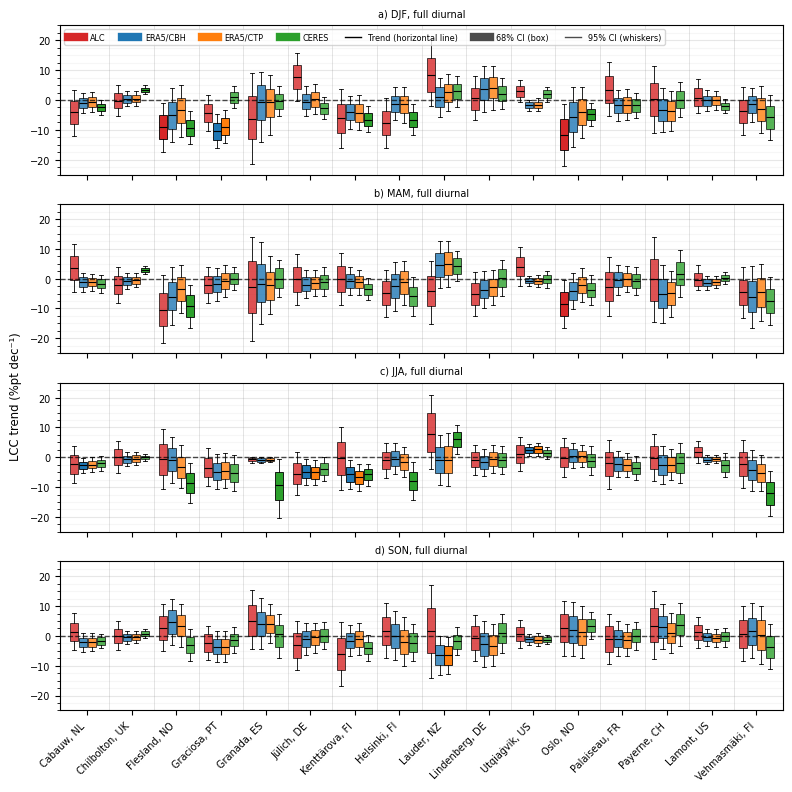

In [ ]:
# Sort sites alphabetically (daytime)
suffix = ""

analysis_sites = (
    ds_trends[f"alc_trend_by_season{suffix}"]
    .dropna(dim="site", how="all")
    .sortby("site", ascending=True)
    .site.values
)

YLIMS = (-25, 25)
scale = 100 * 10  # fraction/yr -> %pt/decade

# 68% CI as box, 95% CI as whiskers
box_sigma_idx = 0
whisker_sigma_idx = 1

plot_configs = [
    {
        "label": "ALC",
        "var_prefix": "alc",
        "offset": -0.30,
        "color": "tab:red",
    },
    {
        "label": "ERA5/CBH",
        "var_prefix": "era5",
        "offset": -0.10,
        "color": "tab:blue",
    },
    {
        "label": "ERA5/CTP",
        "var_prefix": "era5_isccp_non_obscured",
        "offset": 0.10,
        "color": "tab:orange",
    },
    {
        "label": "CERES",
        "var_prefix": "ceres_adj",
        "offset": 0.30,
        "color": "tab:green",
    },
]

box_width = 0.18
seasons = ds_trends.season.values

fig, axes = plt.subplots(
    4,
    1,
    figsize=(figwidth, figwidth * 1.0),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)

for idx, season in enumerate(seasons):
    ax = axes[idx]
    x_base = np.arange(len(analysis_sites))

    for config in plot_configs:
        trend = (
            ds_trends[f"{config['var_prefix']}_trend_by_season{suffix}"].sel(
                site=analysis_sites, season=season
            )
            * scale
        )

        ci = (
            ds_trends[
                f"{config['var_prefix']}_trend_by_season_ci{suffix}"
            ].sel(site=analysis_sites, season=season)
            * scale
        )
        ci_box = ci.isel(sigma_level=box_sigma_idx)
        ci_wh = ci.isel(sigma_level=whisker_sigma_idx)

        stats = []
        positions = []
        alphas = []

        for i, site in enumerate(analysis_sites):
            t = float(trend.sel(site=site).values)
            q1 = float(ci_box.sel(site=site, bound="lower").values)
            q3 = float(ci_box.sel(site=site, bound="upper").values)
            wl = float(ci_wh.sel(site=site, bound="lower").values)
            wu = float(ci_wh.sel(site=site, bound="upper").values)

            if np.isnan([t, q1, q3, wl, wu]).any():
                continue

            stats.append(
                {
                    "med": t,
                    "q1": q1,
                    "q3": q3,
                    "whislo": wl,
                    "whishi": wu,
                    "fliers": [],
                }
            )

            positions.append(x_base[i] + config["offset"])
            alphas.append(get_alpha(t, wu, wl))

        bp = ax.bxp(
            stats,
            positions=positions,
            widths=box_width,
            showfliers=False,
            patch_artist=True,
            manage_ticks=False,
        )

        for j, b in enumerate(bp["boxes"]):
            b.set(
                facecolor=config["color"],
                edgecolor="black",
                linewidth=0.6,
                alpha=alphas[j],
            )

        for w in bp["whiskers"]:
            w.set(color="black", linewidth=0.6)
        for c in bp["caps"]:
            c.set(color="black", linewidth=0.6)
        for m in bp["medians"]:
            m.set(color="black", linewidth=0.8)

    ax.set_ylim(YLIMS)
    ax.axhline(0, color="black", linewidth=1, linestyle="--", alpha=0.7)
    ax.grid(True, alpha=0.3, axis="y")

    for i in range(len(x_base) - 1):
        ax.axvline(x_base[i] + 0.5, color="gray", linewidth=0.5, alpha=0.3)

    ax.set_title(f"{chr(97 + idx)}) {season}, full diurnal", fontsize="medium")
    ax.set_xlim(x_base[0] - 0.6, x_base[-1] + 0.6)

    if idx == len(seasons) - 1:
        ax.set_xticks(x_base)
        ax.set_xticklabels(
            [
                f"{sites.loc[s, 'humanReadableName']}, {sites.loc[s, 'countryCode']}"
                for s in analysis_sites
            ],
            rotation=45,
            ha="right",
        )

    ax.set_yticks(np.arange(YLIMS[0], YLIMS[1] + 2.5, 2.5), minor=True)
    ax.grid(True, which="minor", alpha=0.1)

legend_elements = [
    mlines.Line2D([0], [0], color="tab:red", lw=6, label="ALC"),
    mlines.Line2D([0], [0], color="tab:blue", lw=6, label="ERA5/CBH"),
    mlines.Line2D([0], [0], color="tab:orange", lw=6, label="ERA5/CTP"),
    mlines.Line2D([0], [0], color="tab:green", lw=6, label="CERES"),
    mlines.Line2D(
        [0], [0], color="black", lw=1, label="Trend (horizontal line)"
    ),
    mlines.Line2D([0], [0], color="k", lw=6, label="68% CI (box)", alpha=0.7),
    mlines.Line2D(
        [0],
        [0],
        color="black",
        lw=1,
        linestyle="-",
        label="95% CI (whiskers)",
        alpha=0.7,
    ),
]

fig.supylabel("LCC trend (%pt dec⁻¹)")
axes[0].legend(
    handles=legend_elements, loc="upper left", fontsize="small", ncol=7
)
fig.savefig(
    results_path
    / "alc_era5_era5_isccp_ceres_lcc_trends_by_season_boxwhisker.pdf"
)
plt.show()


#### Crossplot

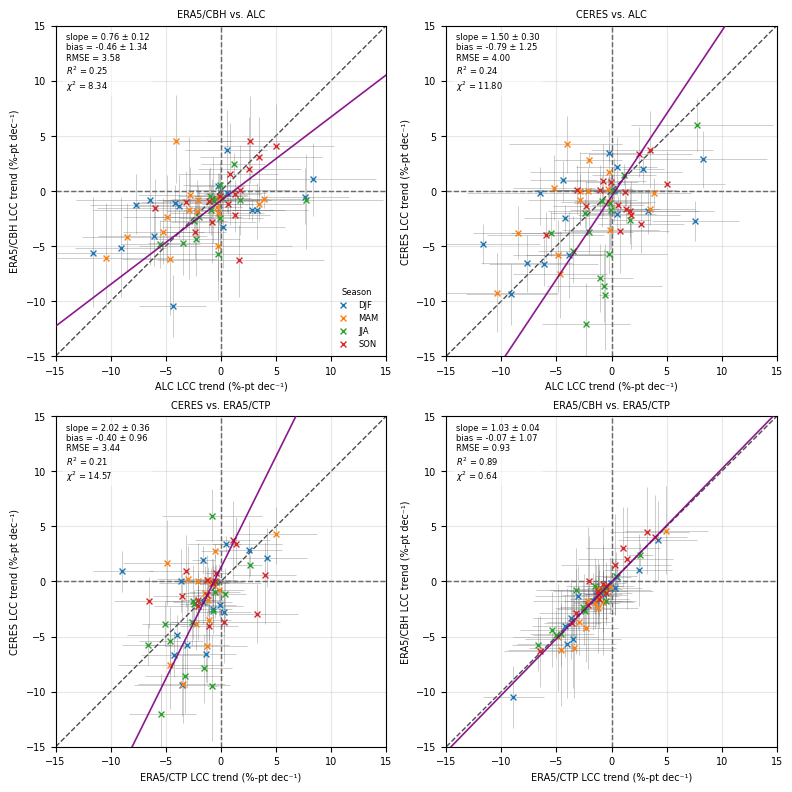

In [ ]:
# Crossplots
suffix = ""
scale = 10 * 100  # % per decade
axes_limits = (-15, 15)

pairwise_series = {
    "ALC": {
        "trend": ds_trends[f"alc_trend_by_season{suffix}"] * scale,
        "ci68": ds_trends[f"alc_trend_by_season_ci{suffix}"].isel(
            sigma_level=0
        )
        * scale,
        "color": "tab:red",
    },
    "ERA5/CBH": {
        "trend": ds_trends[f"era5_trend_by_season{suffix}"] * scale,
        "ci68": ds_trends[f"era5_trend_by_season_ci{suffix}"].isel(
            sigma_level=0
        )
        * scale,
        "color": "tab:blue",
    },
    "ERA5/CTP": {
        "trend": ds_trends[f"era5_isccp_non_obscured_trend_by_season{suffix}"]
        * scale,
        "ci68": ds_trends[
            f"era5_isccp_non_obscured_trend_by_season_ci{suffix}"
        ].isel(sigma_level=0)
        * scale,
        "color": "tab:orange",
    },
    "CERES": {
        "trend": ds_trends[f"ceres_adj_trend_by_season{suffix}"] * scale,
        "ci68": ds_trends[f"ceres_adj_trend_by_season_ci{suffix}"].isel(
            sigma_level=0
        )
        * scale,
        "color": "tab:green",
    },
}

all_trend_values = np.concatenate(
    [v["trend"].values.ravel() for v in pairwise_series.values()]
)
finite_trend_values = all_trend_values[np.isfinite(all_trend_values)]
max_abs_trend = np.max(np.abs(finite_trend_values))
max_trend = np.max(finite_trend_values)
min_trend = np.min(finite_trend_values)
axis_margin = 0.1 * max_abs_trend
max_limit = max_trend + axis_margin
min_limit = min_trend - axis_margin

pair_names = [
    ("ALC", "ERA5/CBH"),
    ("ALC", "CERES"),
    ("ERA5/CTP", "CERES"),
    ("ERA5/CTP", "ERA5/CBH"),
]

season_order = list(ds_trends.season.values)
season_colors = dict(
    zip(season_order, ["tab:blue", "tab:orange", "tab:green", "tab:red"])
)

fig, axes = plt.subplots(
    2,
    2,
    figsize=(figwidth, figwidth),
    constrained_layout=True,
    sharex=False,
    sharey=False,
)

for ax_idx, (ax, (x_name, y_name)) in enumerate(zip(axes.flat, pair_names)):
    x_trend = pairwise_series[x_name]["trend"]
    y_trend = pairwise_series[y_name]["trend"]
    x_ci = pairwise_series[x_name]["ci68"]
    y_ci = pairwise_series[y_name]["ci68"]

    pooled_x, pooled_y = [], []
    pooled_xl, pooled_xu, pooled_yl, pooled_yu = [], [], [], []

    for season in season_order:
        x_s = x_trend.sel(season=season)
        y_s = y_trend.sel(season=season)

        xl_s = x_ci.sel(season=season, bound="lower")
        xu_s = x_ci.sel(season=season, bound="upper")
        yl_s = y_ci.sel(season=season, bound="lower")
        yu_s = y_ci.sel(season=season, bound="upper")

        valid = (
            np.isfinite(x_s.values)
            & np.isfinite(y_s.values)
            & np.isfinite(xl_s.values)
            & np.isfinite(xu_s.values)
            & np.isfinite(yl_s.values)
            & np.isfinite(yu_s.values)
        )
        if not np.any(valid):
            continue

        xv = x_s.values[valid]
        yv = y_s.values[valid]
        xl = xl_s.values[valid]
        xu = xu_s.values[valid]
        yl = yl_s.values[valid]
        yu = yu_s.values[valid]

        xerr = np.vstack([xv - xl, xu - xv])
        yerr = np.vstack([yv - yl, yu - yv])

        ax.errorbar(
            xv,
            yv,
            xerr=xerr,
            yerr=yerr,
            fmt="none",
            ecolor="0.35",
            elinewidth=0.6,
            alpha=0.35,
            zorder=1,
        )
        ax.scatter(
            xv,
            yv,
            s=18,
            color=season_colors[season],
            marker="x",
            linewidth=1,
            zorder=2,
            label=season if ax_idx == 0 else None,
        )

        pooled_x.append(xv)
        pooled_y.append(yv)
        pooled_xl.append(xl)
        pooled_xu.append(xu)
        pooled_yl.append(yl)
        pooled_yu.append(yu)

    if pooled_x:
        x_vals = np.concatenate(pooled_x)
        y_vals = np.concatenate(pooled_y)
        x_lower = np.concatenate(pooled_xl)
        x_upper = np.concatenate(pooled_xu)
        y_lower = np.concatenate(pooled_yl)
        y_upper = np.concatenate(pooled_yu)

        x_mid = 0.5 * (x_lower + x_upper)
        y_mid = 0.5 * (y_lower + y_upper)
        # Clip to minimum intrinsic random error as defined from bootstrap during calibration sensitivity testing
        sx = np.clip(x_upper - x_lower, a_min=0.8, a_max=None)
        sy = np.clip(y_upper - y_lower, a_min=0.8, a_max=None)

        odr_mask = (
            np.isfinite(x_mid)
            & np.isfinite(y_mid)
            & np.isfinite(sx)
            & np.isfinite(sy)
            & (sx > 0)
            & (sy > 0)
        )

        odr_slope, odr_intercept = np.nan, np.nan
        odr_slope_err, odr_intercept_err = np.nan, np.nan

        if np.sum(odr_mask) >= 2:
            model = odr.Model(lambda beta, x: beta[0] * x + beta[1])
            data = odr.RealData(
                x_mid[odr_mask],
                y_mid[odr_mask],
                sx=sx[odr_mask],
                sy=sy[odr_mask],
            )
            p0 = np.polyfit(x_mid[odr_mask], y_mid[odr_mask], 1)
            out = odr.ODR(data, model, beta0=[p0[0], p0[1]]).run()

            odr_slope, odr_intercept = out.beta
            odr_slope_err, odr_intercept_err = out.sd_beta

            xx = np.array([axes_limits[0], axes_limits[1]])
            yy = odr_slope * xx + odr_intercept
            ax.plot(xx, yy, color="purple", linewidth=1.2, alpha=0.9, zorder=3)

        residuals = y_vals - x_vals
        rmse = (
            float(np.sqrt(np.mean(residuals**2))) if residuals.size else np.nan
        )
        corr = np.corrcoef(x_vals, y_vals)[0, 1] if x_vals.size > 1 else np.nan
        r_squared = corr**2 if np.isfinite(corr) else np.nan

        denom = sx**2 + sy**2
        chi_mask = np.isfinite(residuals) & np.isfinite(denom) & (denom > 0)
        chi_sq = (
            np.sum((residuals[chi_mask] ** 2) / denom[chi_mask])
            if np.any(chi_mask)
            else np.nan
        )

        bias = float(np.nanmean(residuals))
        bias_err = (
            1.0
            / np.sum(np.isfinite(residuals))
            * float(np.sqrt(np.sum(denom)))
        )

        ax.text(
            0.03,
            0.98,
            (
                f"slope = {odr_slope:.2f} ± {odr_slope_err:.2f}\n"
                f"bias = {bias:.2f} ± {bias_err:.2f}\n"
                f"RMSE = {rmse:.2f}\n"
                f"$R^2$ = {r_squared:.2f}\n"
                f"$\\chi^2$ = {chi_sq:.2f}"
            ),
            transform=ax.transAxes,
            va="top",
            ha="left",
            fontsize=6,
            bbox={
                "facecolor": "white",
                "edgecolor": "none",
                "alpha": 0.55,
                "pad": 2.0,
            },
        )

    ax.set_xlim(axes_limits)
    ax.set_ylim(axes_limits)
    ax.axhline(0, color="black", linestyle="--", lw=1, alpha=0.7, zorder=0)
    ax.axvline(0, color="black", linestyle="--", lw=1, alpha=0.7, zorder=0)
    ax.plot(
        ax.get_xlim(),
        ax.get_ylim(),
        color="black",
        linestyle="--",
        linewidth=1,
        alpha=0.7,
        zorder=0,
    )
    ax.set_title(f"{y_name} vs. {x_name}", fontsize="medium")
    ax.set_xlabel(f"{x_name} LCC trend (%-pt dec⁻¹)")
    ax.set_ylabel(f"{y_name} LCC trend (%-pt dec⁻¹)")
    ax.grid(True, alpha=0.3)
    # ax.set_xticks(np.sort(np.unique(np.append(ax.get_xticks(), 0.0))))
    # ax.set_yticks(np.sort(np.unique(np.append(ax.get_xticks(), 0.0))))
    # ax.set_xticks(ax.get_yticks())
    ax.set_aspect("equal", adjustable="box")

axes.flat[0].legend(
    title="Season",
    loc="lower right",
    frameon=False,
    ncol=1,
    fontsize=6,
    title_fontsize=6,
)
fig.savefig(
    results_path
    / "alc_era5_era5_isccp_ceres_lcc_pairwise_scatter_seasonal_merged.pdf"
)
plt.show()

In [ ]:
# Seasonal trend diagnostics (easy season-to-season comparison)
suffix = ""
scale = 10 * 100  # fraction/year -> %-pt/decade

variables = {
    "ALC": "alc",
    "ERA5/CBH": "era5",
    "ERA5/CTP": "era5_isccp_non_obscured",
    "CERES": "ceres",
}

season_order = [
    s for s in ["DJF", "MAM", "JJA", "SON"] if s in ds_trends.season.values
]
if not season_order:
    season_order = list(ds_trends.season.values)


def _finite_vals(arr):
    arr = np.asarray(arr, dtype=float)
    return arr[np.isfinite(arr)]


print("#" * 96)
print("SEASONAL TREND DIAGNOSTICS (%-pt/decade)")
print("#" * 96)
print("Metrics:")
print("  mean trend      : average slope across sites")
print(
    "  trend std       : consistency across sites (lower is more consistent)"
)
print("  mean CI68 width : average (upper-lower) at sigma_level=0")
print("  mean CI95 width : average (upper-lower) at sigma_level=1")

for var_label, var_prefix in variables.items():
    print("\n" + "=" * 96)
    print(f"Variable: {var_label}")
    print("=" * 96)
    print(
        f"{'Season':<8} {'N':>3} {'Mean trend':>12} {'Trend STD':>12} "
        f"{'Mean CI68':>12} {'Mean CI95':>12}"
    )
    print("-" * 96)

    for season in season_order:
        vals = (
            ds_trends[f"{var_prefix}_trend_by_season{suffix}"]
            .sel(site=analysis_sites, season=season)
            .values
            * scale
        )
        ci68 = (
            ds_trends[f"{var_prefix}_trend_by_season_ci{suffix}"]
            .sel(site=analysis_sites, season=season)
            .isel(sigma_level=0)
            * scale
        )
        ci95 = (
            ds_trends[f"{var_prefix}_trend_by_season_ci{suffix}"]
            .sel(site=analysis_sites, season=season)
            .isel(sigma_level=1)
            * scale
        )

        vals_f = _finite_vals(vals)
        ci68_w = _finite_vals(
            ci68.sel(bound="upper").values - ci68.sel(bound="lower").values
        )
        ci95_w = _finite_vals(
            ci95.sel(bound="upper").values - ci95.sel(bound="lower").values
        )

        n_valid = int(vals_f.size)
        mean_trend = float(np.nanmean(vals_f)) if n_valid else np.nan
        std_trend = float(np.nanstd(vals_f)) if n_valid else np.nan
        mean_ci68 = float(np.nanmean(ci68_w)) if ci68_w.size else np.nan
        mean_ci95 = float(np.nanmean(ci95_w)) if ci95_w.size else np.nan

        print(
            f"{season:<8} {n_valid:>3d} "
            f"{mean_trend:>+12.3f} {std_trend:>12.3f} "
            f"{mean_ci68:>12.3f} {mean_ci95:>12.3f}"
        )

# Cross-variable pooled comparison by season
print("\n" + "#" * 96)
print("POOLED ACROSS VARIABLES (all sites + all variables)")
print("#" * 96)
print(
    f"{'Season':<8} {'N pooled':>8} {'Mean trend':>12} {'Trend STD':>12} "
    f"{'Mean CI68':>12} {'Mean CI95':>12}"
)
print("-" * 96)

pooled_summary = {}
for season in season_order:
    pooled_trends = []
    pooled_ci68_w = []
    pooled_ci95_w = []

    for var_prefix in variables.values():
        vals = (
            ds_trends[f"{var_prefix}_trend_by_season{suffix}"]
            .sel(site=analysis_sites, season=season)
            .values
            * scale
        )
        ci68 = (
            ds_trends[f"{var_prefix}_trend_by_season_ci{suffix}"]
            .sel(site=analysis_sites, season=season)
            .isel(sigma_level=0)
            * scale
        )
        ci95 = (
            ds_trends[f"{var_prefix}_trend_by_season_ci{suffix}"]
            .sel(site=analysis_sites, season=season)
            .isel(sigma_level=1)
            * scale
        )

        pooled_trends.append(_finite_vals(vals))
        pooled_ci68_w.append(
            _finite_vals(
                ci68.sel(bound="upper").values - ci68.sel(bound="lower").values
            )
        )
        pooled_ci95_w.append(
            _finite_vals(
                ci95.sel(bound="upper").values - ci95.sel(bound="lower").values
            )
        )

    pooled_trends = (
        np.concatenate([v for v in pooled_trends if v.size])
        if pooled_trends
        else np.array([])
    )
    pooled_ci68_w = (
        np.concatenate([v for v in pooled_ci68_w if v.size])
        if pooled_ci68_w
        else np.array([])
    )
    pooled_ci95_w = (
        np.concatenate([v for v in pooled_ci95_w if v.size])
        if pooled_ci95_w
        else np.array([])
    )

    n_pooled = int(pooled_trends.size)
    mean_trend = float(np.nanmean(pooled_trends)) if n_pooled else np.nan
    std_trend = float(np.nanstd(pooled_trends)) if n_pooled else np.nan
    mean_ci68 = (
        float(np.nanmean(pooled_ci68_w)) if pooled_ci68_w.size else np.nan
    )
    mean_ci95 = (
        float(np.nanmean(pooled_ci95_w)) if pooled_ci95_w.size else np.nan
    )

    pooled_summary[season] = {
        "n": n_pooled,
        "mean": mean_trend,
        "std": std_trend,
        "ci68": mean_ci68,
        "ci95": mean_ci95,
    }

    print(
        f"{season:<8} {n_pooled:>8d} "
        f"{mean_trend:>+12.3f} {std_trend:>12.3f} "
        f"{mean_ci68:>12.3f} {mean_ci95:>12.3f}"
    )

print("\n" + "#" * 96)
print("SEASON RANKING SNAPSHOT")
print("#" * 96)


def _rank_line(metric_key, desc, reverse=False):
    valid = [
        (s, pooled_summary[s][metric_key])
        for s in season_order
        if np.isfinite(pooled_summary[s][metric_key])
    ]
    valid_sorted = sorted(valid, key=lambda x: x[1], reverse=reverse)
    txt = " > ".join(
        [
            f"{s} ({v:+.3f})" if metric_key == "mean" else f"{s} ({v:.3f})"
            for s, v in valid_sorted
        ]
    )
    print(f"{desc:<30}: {txt}")


_rank_line("mean", "Highest mean trend", reverse=True)
_rank_line("std", "Lowest trend STD")
_rank_line("ci68", "Narrowest mean CI68")
_rank_line("ci95", "Narrowest mean CI95")

################################################################################################
SEASONAL TREND DIAGNOSTICS (%-pt/decade)
################################################################################################
Metrics:
  mean trend      : average slope across sites
  trend std       : consistency across sites (lower is more consistent)
  mean CI68 width : average (upper-lower) at sigma_level=0
  mean CI95 width : average (upper-lower) at sigma_level=1

Variable: ALC
Season     N   Mean trend    Trend STD    Mean CI68    Mean CI95
------------------------------------------------------------------------------------------------
DJF       16       -1.895        5.568        8.402       16.936
MAM       16       -2.585        3.683        8.901       17.934
JJA       16       -0.537        2.740        6.915       13.779
SON       16       +0.483        2.617        8.372       16.755

Variable: ERA5/CBH
Season     N   Mean trend    Trend STD    Mean CI68    Mean CI

KeyError: "No variable named 'modis_trend_by_season'. Did you mean one of ('alc_trend_by_season', 'era5_trend_by_season', 'alc_trend_by_season_ci', 'ceres_adj_trend_by_season', 'era5_trend_by_season_ci', 'alc_trend_by_season_std', 'era5_trend_by_season_std', 'ceres_adj_trend_by_season_ci', 'alc_trend_by_season_pvalue', 'ceres_adj_trend_by_season_std')?"

# PDFs of the trend estimates

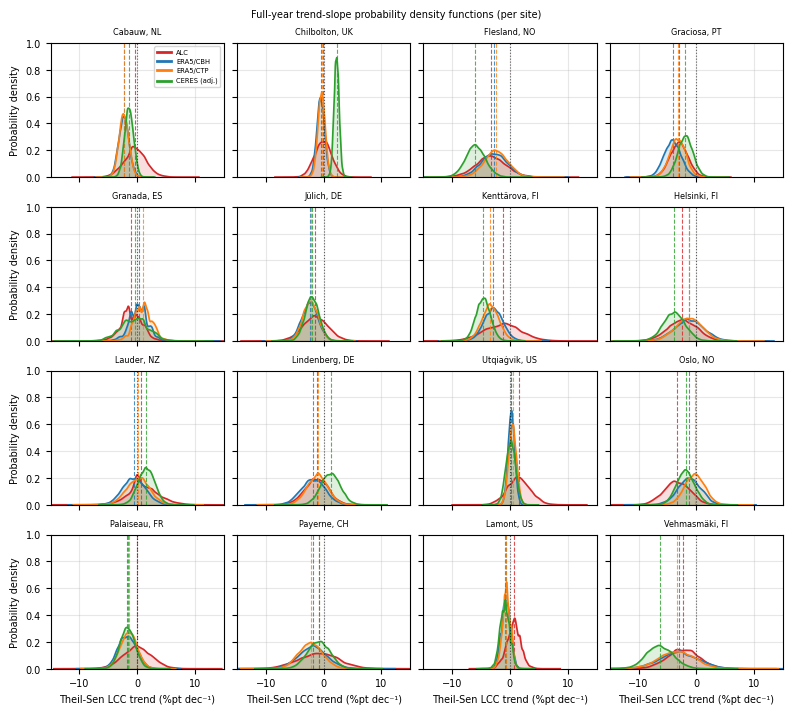

In [ ]:
import pandas as pd
from scipy.stats import gaussian_kde
import matplotlib.lines as mlines

suffix = "_daytime"
scale = 10 * 100  # fraction/year -> %-pt/decade
n_mc_samples = 20_000  # inverse-transform samples drawn per dataset-site pair

trend_slope_distributions_path = (
    get_data_paths().level4_trends_slope_distributions
)

# Full-year trend-slope quantile functions, one parquet file per
# dataset-site pair, written by entrypoints/compute_level4_trends.py. Each
# file stores the MK-test-inverted sampling distribution of the trend
# estimate (probability_level -> quantile_value_per_year), i.e. the same
# construction used for the reported confidence intervals, NOT the
# empirical distribution of the underlying pairwise Sen slopes.
dataset_styles = {
    "alc": ("ALC", "tab:red"),
    "era5": ("ERA5/CBH", "tab:blue"),
    "era5_isccp_non_obscured": ("ERA5/CTP", "tab:orange"),
    "ceres_adj": ("CERES (adj.)", "tab:green"),
}

rng = np.random.default_rng(0)

n_cols = 4
n_rows = int(np.ceil(len(analysis_sites) / n_cols))

fig, axes = plt.subplots(
    n_rows,
    n_cols,
    figsize=(figwidth, figwidth * n_rows / n_cols * 0.9),
    constrained_layout=True,
    sharex=True,
    sharey=True,
)
axes_flat = np.atleast_1d(axes).flat

for ax, site in zip(axes_flat, analysis_sites):
    any_plotted = False

    for dataset_name, (label, color) in dataset_styles.items():
        df = load_trend_slope_quantile_function(dataset_name, site, suffix)
        if df is None:
            continue

        probability_levels = df["probability_level"].values
        quantile_values = df["quantile_value_per_year"].values * scale
        if np.unique(quantile_values).size < 2:
            continue

        # Inverse-transform sampling: draw uniform probabilities and map
        # them through the stored quantile function to obtain samples from
        # the actual (MK-test-inverted) trend-slope distribution, then KDE
        # those samples to approximate the PDF.
        uniform_draws = rng.uniform(0.0, 1.0, size=n_mc_samples)
        mc_samples = np.interp(
            uniform_draws, probability_levels, quantile_values
        )

        kde = gaussian_kde(mc_samples)
        x_grid = np.linspace(quantile_values.min(), quantile_values.max(), 512)
        density = kde(x_grid)
        ax.plot(x_grid, density, color=color, lw=1.2, label=label)
        ax.fill_between(x_grid, density, color=color, alpha=0.15)

        slope_val = float(df["slope_per_year"].iloc[0]) * scale
        ax.axvline(slope_val, color=color, linestyle="--", lw=0.8, alpha=0.8)

        any_plotted = True

        ax.set_xlim(-15, 15)
        ax.set_ylim(0, 1)

    ax.axvline(0, color="black", linestyle=":", lw=0.8, alpha=0.6)
    ax.set_title(
        f"{sites.loc[site, 'humanReadableName']}, {sites.loc[site, 'countryCode']}",
        fontsize="small",
    )
    ax.grid(True, alpha=0.3)

    if not any_plotted:
        ax.set_visible(False)

for ax in list(axes_flat)[len(analysis_sites) :]:
    ax.set_visible(False)

for ax in axes[:, 0]:
    ax.set_ylabel("Probability density")
for ax in axes[-1, :]:
    ax.set_xlabel("LCC trend (%pt dec⁻¹)")

legend_elements = [
    mlines.Line2D([0], [0], color=color, lw=2, label=label)
    for label, color in dataset_styles.values()
]
np.atleast_1d(axes).flat[0].legend(
    handles=legend_elements, loc="upper right", fontsize="x-small"
)

fig.suptitle(
    "Full-year trend-slope probability density functions (per site)",
    fontsize="medium",
)
fig.savefig(
    results_path / "alc_era5_era5_isccp_ceres_lcc_trend_pdfs.pdf", dpi=300
)
plt.show()


# Mean trends and their distributions


Monte Carlo mean trend sampling (_daytime)


,n_sites,mean_trend,ci68_lower,ci68_upper,ci95_lower,ci95_upper,SE
dataset,,,,,,,
ALC,16,-1.08,-1.66,-0.81,-2.04,-0.12,0.58
ERA5/CBH,16,-1.64,-2.10,-1.43,-2.40,-0.89,0.46
ERA5/CTP,16,-1.41,-1.83,-1.21,-2.10,-0.72,0.42
CERES (adj.),16,-1.65,-2.03,-1.48,-2.27,-1.03,0.38


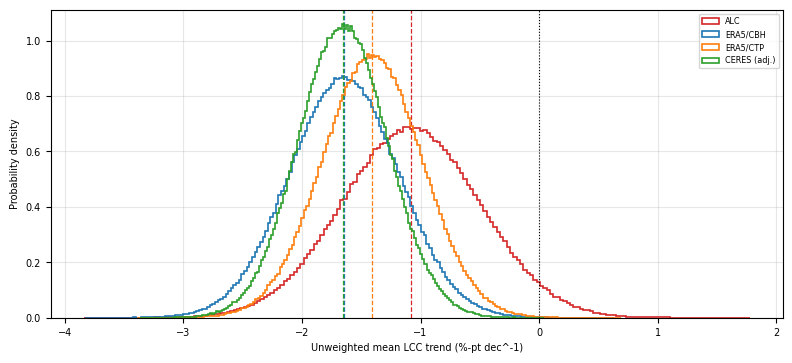


Monte Carlo mean trend sampling (_nighttime)


,n_sites,mean_trend,ci68_lower,ci68_upper,ci95_lower,ci95_upper,SE
dataset,,,,,,,
ALC,16,-0.51,-1.07,-0.24,-1.43,0.42,0.56
ERA5/CBH,16,-1.00,-1.46,-0.78,-1.76,-0.23,0.47
ERA5/CTP,16,-0.99,-1.41,-0.79,-1.69,-0.29,0.42
CERES (adj.),16,-1.81,-2.16,-1.65,-2.40,-1.23,0.35


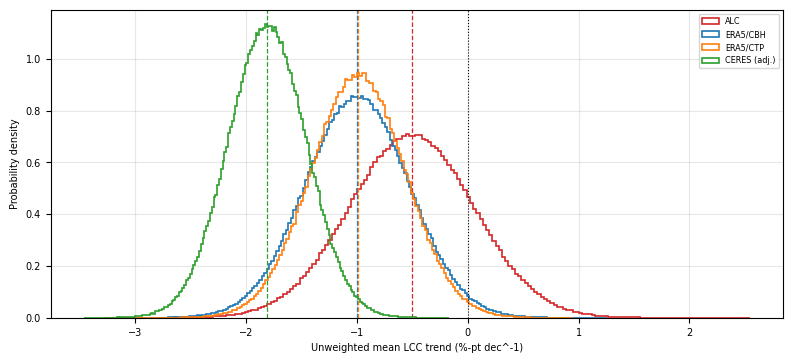

In [ ]:
# Monte Carlo distributions of the unweighted mean trend across sites.
n_mc_mean_samples = 1_000_000
rng = np.random.default_rng(1)

for suffix in ("_daytime", "_nighttime"):
    print(f"\nMonte Carlo mean trend sampling ({suffix or 'full diurnal'})")
    mean_trend_samples = {}
    mean_trend_summary = []
    for dataset_name, (label, color) in dataset_styles.items():
        site_draws = []

        for site in analysis_sites:
            df = load_trend_slope_quantile_function(dataset_name, site, suffix)
            if df is None:
                continue

            probability_levels = df["probability_level"].to_numpy(dtype=float)
            quantile_values = (
                df["quantile_value_per_year"].to_numpy(dtype=float) * scale
            )
            valid = np.isfinite(probability_levels) & np.isfinite(
                quantile_values
            )
            probability_levels = probability_levels[valid]
            quantile_values = quantile_values[valid]
            if (
                probability_levels.size < 2
                or np.unique(quantile_values).size < 2
            ):
                continue

            order = np.argsort(probability_levels)
            uniform_draws = rng.uniform(0.0, 1.0, size=n_mc_mean_samples)
            site_draws.append(
                np.interp(
                    uniform_draws,
                    probability_levels[order],
                    quantile_values[order],
                )
            )

        if not site_draws:
            continue

        # Each row is one simultaneous draw across all available sites.
        draws = np.column_stack(site_draws)
        mean_samples = draws.mean(axis=1)
        mean_trend_samples[dataset_name] = mean_samples

        p32, p68 = np.quantile(mean_samples, [0.16, 0.68])
        p05, p95 = np.quantile(mean_samples, [0.05, 0.95])
        se = np.std(mean_samples, ddof=1)
        mean_trend_summary.append(
            {
                "dataset": label,
                "n_sites": draws.shape[1],
                "mean_trend": mean_samples.mean(),
                "ci68_lower": p32,
                "ci68_upper": p68,
                "ci95_lower": p05,
                "ci95_upper": p95,
                "SE": se,
            }
        )

    mean_trend_summary = pd.DataFrame(mean_trend_summary).set_index("dataset")
    display(mean_trend_summary.round(2))

    fig, ax = plt.subplots(
        figsize=(figwidth, figwidth * 0.45), constrained_layout=True
    )
    for dataset_name, (label, color) in dataset_styles.items():
        if dataset_name not in mean_trend_samples:
            continue
        samples = mean_trend_samples[dataset_name]
        ax.hist(
            samples,
            bins=200,
            density=True,
            histtype="step",
            linewidth=1.2,
            color=color,
            label=label,
        )
        ax.axvline(samples.mean(), color=color, linestyle="--", linewidth=0.9)

    ax.axvline(0, color="black", linestyle=":", linewidth=0.8)
    ax.set_xlabel("Unweighted mean LCC trend (%-pt dec^-1)")
    ax.set_ylabel("Probability density")
    ax.grid(True, alpha=0.3)
    ax.legend(fontsize="small")
    fig.savefig(
        results_path
        / f"alc_era5_era5_isccp_ceres_mean_lcc_trend_mc_pdfs_{suffix}.pdf",
        dpi=300,
    )
    plt.show()